# Libraries

In [48]:
from _utils import *
from _regex_functions import *

# Import Data

In [49]:
raw_excel_df = pd.read_excel(ANNOTATIONS_FP)

keep_cols = ['row_id', 'file_hash', 'type','subtype_1','subtype_confidence','notes_free_text','label']

ant_df = raw_excel_df \
    .query("annotated == 'y'") \
    .query("type != 'Exclude'") \
    .query("type != 'I Multi'") \
    .query("type != 'R Multi'") \
    .query("type != 'I Cl'") \
    .query("subtype_confidence != '1 - Not confident at all'") \
    .assign(
        label=lambda df: df.apply(
            lambda r: map_subtype(r.type, r.subtype_1),
            axis=1
        )
    ) \
    .query("label != 'R Other (Rare)'") \
    .loc[:, keep_cols]

ant_df.to_csv(PIPELINE_DATA_DIR / "ant_df.csv",  index=False)

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed


In [50]:
ant_df.shape

(1100, 7)

In [51]:
raw_gpt_bl = pd.read_excel(GPT_DIR / "gpt_baseline_v1.xlsx").rename(columns={"hash":"file_hash","mechanisms":"gpt_pred_subtype"})
raw_gpt_aug = pd.read_excel(GPT_DIR / "gpt_with_heuristics_v1.xlsx").rename(columns={"hash":"file_hash","mechanisms":"gpt_pred_subtype"})
label_df = pd.read_csv(PIPELINE_DATA_DIR / "split_df2_with_labels.csv")
TEST_SAMPLES = label_df.query("set == 'test'")["file_hash"].tolist()

In [52]:
def clean_gpt(
    raw_gpt_df,
    label_df,
    annotated_samples,
    map_type,
    suffix=None
):

    df = (
        raw_gpt_df
        .query("file_hash in @annotated_samples")
        .assign(gpt_pred_subtype=lambda df: df["gpt_pred_subtype"].str.split(","))
        .explode("gpt_pred_subtype")
    )

    df["gpt_pred_subtype"] = df["gpt_pred_subtype"].str.strip()

    df = (
        df
        .merge(label_df, how="left")
        .assign(
            gpt_pred_type=lambda df: df["gpt_pred_subtype"].apply(map_type)
        )
        .groupby("file_hash", as_index=False)
        .agg(
            gpt_pred_subtype=("gpt_pred_subtype", lambda x: ", ".join(sorted(set(x)))),
            gpt_pred_type=("gpt_pred_type", lambda x: ", ".join(sorted(set(x))))
        )
        .merge(label_df, how="left")
        .query("set == 'test'")
        .assign(
            gpt_subtype_set=lambda df: df["gpt_pred_subtype"].apply(to_set),
            gpt_type_set=lambda df: df["gpt_pred_type"].apply(to_set),
            gpt_subtype_set_size=lambda df: df["gpt_subtype_set"].str.len(),
            gpt_type_set_size=lambda df: df["gpt_type_set"].str.len(),
            subtype_correct=lambda df: df.apply(
                lambda r: r["label"] in r["gpt_subtype_set"], axis=1
            ),
            type_correct=lambda df: df.apply(
                lambda r: r["type"] in r["gpt_type_set"], axis=1
            )
        )
        .rename(columns={
            "type": "true_type",
            "label": "true_subtype",
            "gpt_pred_subtype": "gpt_pred_subtype_og",
            "gpt_pred_type": "gpt_pred_type_og"
        })
        .assign(
            gpt_pred_subtype=lambda df: np.where(
                df["subtype_correct"],
                df["true_subtype"],
                np.where(
                    df["gpt_subtype_set_size"] > 1,
                    "Z Neither",
                    df["gpt_pred_subtype_og"]
                )
            ),
            gpt_pred_type=lambda df: np.where(
                df["type_correct"],
                df["true_type"],
                np.where(
                    df["gpt_type_set_size"] > 1,
                    "Neither",
                    df["gpt_pred_type_og"]
                )
            )
        )
        .assign(
            gpt_pred_type=lambda df: df["gpt_pred_type"].replace(
                "R Other", "Receptor"
            )
        )
    )

    if suffix is not None:
        df = df.rename(columns={
            "gpt_pred_type": f"gpt_{suffix}_pred_type",
            "gpt_pred_subtype": f"gpt_{suffix}_pred_subtype"
        })

    return df


gpt_bl2 = clean_gpt(
    raw_gpt_df=raw_gpt_bl,
    label_df=label_df,
    annotated_samples=TEST_SAMPLES,
    map_type=map_type,
    suffix="bl"
)

gpt_aug2 = clean_gpt(
    raw_gpt_df=raw_gpt_aug,
    label_df=label_df,
    annotated_samples=TEST_SAMPLES,
    map_type=map_type,
    suffix="aug"
)

gpt_bl2.to_csv(PIPELINE_DATA_DIR / "gpt_bl2.csv",  index=False)
gpt_aug2.to_csv(PIPELINE_DATA_DIR / "gpt_aug2.csv",  index=False)

gpt_both = (
    gpt_bl2
    .merge(
        gpt_aug2,
        on=["file_hash", "true_type", "true_subtype"],
        how="left"
    )
)

gpt_both.to_csv(PIPELINE_DATA_DIR / "gpt_both.csv",  index=False)



In [53]:
combined_df = pd.read_csv(PIPELINE_DATA_DIR / "sim_features_combined.csv")

In [54]:
sim_df = (
    combined_df
    .drop_duplicates(subset="mod_file")
    .rename(columns=lambda col: col if col in ['mod_file', 'mod_name'] else f"{col}_simfeat")
    .assign(file_hash=lambda df: df['mod_file'].str.replace(r'\.mod$', '', regex=True))
    .drop(columns=["suffix_simfeat","source_file_simfeat","source_folder_simfeat"])
    .reset_index(drop=True)
)

sim_df.to_csv(PIPELINE_DATA_DIR / "sim_df.csv",  index=False)


In [55]:
sim_df.shape

(749, 43)

In [56]:
json_df = pd.read_json(JSON_FP)

In [57]:
json_df.shape

(1301, 16)

# Feature Engineering

In [58]:
# Regex patterns (non-capturing; match at line start with MULTILINE)
pattern_any = r'^\s*(?:INCLUDE\s+"[^"]+"|#include\s*[<"][^">]+[>"])'
pattern_cap = r'^\s*(?:INCLUDE\s+"[^"]+")'

# json_df2 build
json_df2 = (
    json_df
    .merge(ant_df, on=["row_id", "file_hash"], how="inner")
    .assign(
        mod_name = lambda df: df["url"].apply(get_fname),
        suffix = lambda df: df["content"].apply(get_suffix),
        read_ion = lambda df: df["content"].apply(get_read_ion),
        read_ion2 = lambda df: df["read_ion"].apply(
            lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []
        ),
        write_ion = lambda df: df["content"].apply(get_write_ion),
        write_ion2 = lambda df: df["write_ion"].apply(
            lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else []
        ),
        parameter = lambda df: df["content"].apply(get_parameter),
        state = lambda df: df["content"].apply(get_derivative),
        net_receive = lambda df: df["content"].apply(get_net_receive),
        point_process = lambda df: df["content"].apply(get_point_process),
        nonspecific_current = lambda df: df["content"].apply(get_nonspecific_current),
         parameter_yn = lambda df: df["parameter"].apply(
            lambda x: 1 if isinstance(x, dict) and len(x) > 0 else (1 if pd.notna(x) and not isinstance(x, dict) else 0)
        ),
        state_yn = lambda df: df["state"].apply(
            lambda x: 1 if isinstance(x, (list, int)) and (len(x) > 0 if isinstance(x, list) else x > 0) else (1 if pd.notna(x) and not isinstance(x, (list, int)) else 0)
        ),

        
        states_count = lambda df: df["state"].apply(lambda x: len(x) if isinstance(x, list) else 0),
        clamp_yn = lambda df: df.apply(lambda row: has_electrode_or_clamp(row["mod_name"], row["content"]), axis=1),
        suffix_yn = lambda df: df["suffix"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (0 if pd.isna(x) or x == "none" else 1)
        ),
        point_process_yn = lambda df: df["point_process"].apply(lambda x: 1 if pd.notna(x) else 0),
        net_receive_yn = lambda df: df["net_receive"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)
        ),
        i_nonspecific_yn = lambda df: df["nonspecific_current"].apply(
            lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0)
        ),
        not_ion_channel_yn = lambda df: (
            (df["suffix_yn"] == 0) & df["read_ion"].isna() & df["write_ion"].isna() & df["nonspecific_current"].isna()
        ).astype(int),
        not_receptor_yn = lambda df: (
            (df["point_process_yn"] == 0) & (df["net_receive_yn"] == 0)
        ).astype(int),

        mg_yn = lambda df: df["content"].apply(has_mg),
        verbatim_yn = lambda df: df["content"].apply(has_verbatim),
        verbatim_count = lambda df: df["content"].apply(get_verbatim_length),
        pointer_yn = lambda df: df["content"].apply(has_pointer),




        # Include indicators and line counts
        include_yn = lambda df: df['content'].str.contains(pattern_any, case=False, na=False, flags=re.MULTILINE),
        include_cap_yn = lambda df: df['content'].str.contains(pattern_cap, case=True, na=False, flags=re.MULTILINE)

    )
    .reset_index(drop=True)
)


In [59]:
#View(json_df2[["pointer_yn","url"]].sort_values("pointer_yn", ascending=False).head())
#View(json_df2[["url","has_verbatim_yn","verbatim_count"]].query("has_verbatim_yn ==1").sort_values("verbatim_count", ascending=False))

In [60]:
# Use MultiLabelBinarizer separately for read and write ions
# Reset index before merging to avoid index mismatches
mlb_read = MultiLabelBinarizer()
read_df = pd.DataFrame(mlb_read.fit_transform(json_df2['read_ion2']), 
                                columns=[f'read_{col}_yn' for col in mlb_read.classes_]).reset_index(drop=True)

mlb_write = MultiLabelBinarizer()
write_df = pd.DataFrame(mlb_write.fit_transform(json_df2['write_ion2']), 
                                 columns=[f'write_{col}_yn' for col in mlb_write.classes_]).reset_index(drop=True)

In [61]:
json_df3 = json_df2.drop(columns=['read_ion2', 'write_ion2']).join(read_df, rsuffix='_read_dup').join(write_df, rsuffix='_write_dup').dropna(subset=["label"])

In [62]:
#json_df3["created_year"] = pd.to_datetime(json_df3["created_date"], errors='coerce').dt.year
#print(json_df3["created_year"].agg(['min', 'max', 'mean']))

In [63]:
#Number of mod files in sample that have features derived from simulation
json_df3.merge(sim_df, how="inner", on="file_hash").shape[0]

674

In [64]:
json_df4 = json_df3.merge(sim_df, how="left", on="file_hash")

In [65]:
EXTERNAL_VALIDATION_SET = json_df4.query("row_id > 1000")["file_hash"].tolist()

In [66]:
print("Total shape", json_df4.shape)
print("Total unique currents/receptors", json_df4["row_id"].nunique())

Total shape (1100, 125)
Total unique currents/receptors 1100


In [67]:
df_pre = json_df4.set_index('file_hash').filter(regex=r'(_yn|_count|label|type|volt_min|volt_max|_simfeat)$')

In [68]:
df_pre.shape

(1100, 96)

In [69]:
df_pre["type"].value_counts()

type
I K         334
Neither     273
I Na        152
Receptor    134
I Ca        124
I H          47
I Other      36
Name: count, dtype: int64

In [70]:
df_pre["label"].value_counts()

label
Z Neither                   273
I K (A-type)                 95
I Na (Transient)             87
I K (Delayed Rectifier)      82
I Ca (HVA)                   78
I K (Ca-activated)           69
I K (Rare)                   48
I H                          47
R Glutamate (NMDA)           42
I K (M-type)                 40
R GABA                       37
I Other (Rare)               36
R Glutamate (AMPA)           36
I Ca (T-type LT)             32
I Na (Rare)                  24
I Na (Persistent)            22
R Other (General)            19
I Na (Slow inactivation)     19
I Ca (Rare)                  14
Name: count, dtype: int64

In [71]:
df_pre.to_csv(PIPELINE_DATA_DIR / "pre_df.csv")

## Splitting into Train and Test Sets

In [72]:

def clean_numeric_columns(df):
    """Clean column names and enforce numeric dtype for object columns."""
    df = df.copy()
    df.columns = df.columns.astype(str).str.replace(r"[\[\]<>]", "_", regex=True)
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col], errors="raise")
    return df

def encode_labels(train_s, test_s=None):
    le = LabelEncoder().fit(pd.Series(train_s).astype(str))
    y_tr = le.transform(pd.Series(train_s).astype(str))
    y_te = le.transform(pd.Series(test_s).astype(str)) if test_s is not None else None
    return le, y_tr, y_te


def plot_confusion(y_true, y_pred, labels, title, normalize=None, figsize=(10, 7)):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()


def xgb_gain_importance(estimator, feature_names):
    """Return gain-based importances mapped to real feature names as a sorted Series."""
    booster = estimator.get_booster()
    score = booster.get_score(importance_type="gain")  # dict: {key -> gain}
    mapped = {}
    for k, v in score.items():
        if isinstance(k, str) and k.startswith('f') and k[1:].isdigit():
            idx = int(k[1:])
            name = feature_names[idx] if idx < len(feature_names) else k
        else:
            name = k
        mapped[name] = float(v)
    s = pd.Series(mapped, dtype=float)
    s = s.reindex(feature_names).fillna(0.0).sort_values(ascending=False)
    return s

def plot_top_features(imp_series, title, topn=15, figsize=(9, 6)):
    top = imp_series.head(topn)[::-1]
    plt.figure(figsize=figsize)
    top.plot.barh()
    plt.title(title); plt.xlabel("Gain importance"); plt.ylabel("Feature")
    plt.tight_layout(); plt.show()

In [73]:
SEED = 6
np.random.seed(SEED)

#main excludes the external testing set (has train+validation)
df_main = df_pre[~df_pre.index.isin(EXTERNAL_VALIDATION_SET)]
X_main = df_main.drop(columns=["label","type"])
y_type = df_main["type"].astype(str)
y_subtype = df_main["label"].astype(str)
X_train, X_val, y_type_train, y_type_val, y_subtype_train, y_subtype_val = train_test_split(
    X_main, y_type, y_subtype, test_size=0.20, stratify=y_subtype, random_state=SEED
)
df_test = df_pre[df_pre.index.isin(EXTERNAL_VALIDATION_SET)]
X_test = df_test.drop(columns=["label", "type"])
y_subtype_test = df_test["label"].astype(str)
y_type_test = df_test["type"].astype(str)


TRAIN_SET = X_train.index.tolist()
VAL_SET = X_val.index.tolist()

df_train = pd.DataFrame({"file_hash": TRAIN_SET, "set": "train"})
df_test  = pd.DataFrame({"file_hash": EXTERNAL_VALIDATION_SET, "set": "test"})
df_val   = pd.DataFrame({"file_hash": VAL_SET, "set": "val"})
df_split = pd.concat([df_train, df_test, df_val], ignore_index=True)

df_pre_label = df_pre.reset_index().loc[:,["file_hash","type","label"]]
df_split2 = df_pre_label.merge(df_split, how='left', on='file_hash')
df_split2.to_csv(PIPELINE_DATA_DIR / "split_df2_with_labels.csv", index=False)


## Feature Selection Pipeline (Feature-Engine)

In [74]:
# Encode subtypes for selection scoring
subtype_encoder, y_subtype_train_enc, _ = encode_labels(y_subtype_train)

y_subtype_val_enc = subtype_encoder.transform(y_subtype_val)
y_subtype_test_enc = subtype_encoder.transform(y_subtype_test)

# Drop columns with ≥99% missing values
threshold = 0.99
missing_fraction = X_train.isna().mean()
cols_to_drop = missing_fraction[missing_fraction >= threshold].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with ≥{int(threshold*100)}% missingness.")

X_train_clean = X_train.drop(columns=cols_to_drop)
X_val_clean  = X_val.drop(columns=cols_to_drop, errors="ignore")
X_test_clean  = X_test.drop(columns=cols_to_drop, errors="ignore")

# DEBUG: Check if columns match
print(f"X_train_clean columns: {X_train_clean.shape[1]}")
print(f"X_val_clean columns: {X_val_clean.shape[1]}")
print(f"X_test_clean columns: {X_test_clean.shape[1]}")

# Check for missing columns in test
train_cols = set(X_train_clean.columns)
test_cols = set(X_test_clean.columns)
missing_in_test = train_cols - test_cols
extra_in_test = test_cols - train_cols

print(f"Columns in train but not in test: {len(missing_in_test)}")
if missing_in_test:
    print(f"Missing columns: {list(missing_in_test)[:10]}")  # Show first 10
    
print(f"Columns in test but not in train: {len(extra_in_test)}")
if extra_in_test:
    print(f"Extra columns: {list(extra_in_test)[:10]}")  # Show first 10

# FIX: Align columns - keep only common columns OR add missing columns with NaN
# Option 1: Keep only columns that exist in train
X_test_clean = X_test_clean[X_train_clean.columns]
X_val_clean = X_val_clean[X_train_clean.columns]

print(f"\nAfter alignment:")
print(f"X_train_clean columns: {X_train_clean.shape[1]}")
print(f"X_val_clean columns: {X_val_clean.shape[1]}")
print(f"X_test_clean columns: {X_test_clean.shape[1]}")

# Lists AFTER dropping
binary_list     = [c for c in X_train_clean.columns if c.endswith("_yn")]
continuous_list = [c for c in X_train_clean.columns if any(s in c for s in ["_min", "_max", "_simfeat"])]
discrete_list   = [c for c in X_train_clean.columns if c.endswith("_count")]

# Cast binaries to category
X_train_clean[binary_list] = X_train_clean[binary_list].astype("category")
X_val_clean[binary_list]  = X_val_clean[binary_list].astype("category")
X_test_clean[binary_list]  = X_test_clean[binary_list].astype("category")

# Preprocess pipeline (impute/scale/discretize)
feature_preprocess_pipeline = Pipeline(steps=[
    ("missing_indicator", AddMissingIndicator(variables=continuous_list)),
    ("arbitrary_number_imputer", ArbitraryNumberImputer(arbitrary_number=0, variables=discrete_list)),
    ("median_imputer", MeanMedianImputer(imputation_method="median", variables=continuous_list)),
    ("binary_imputer", CategoricalImputer(fill_value="0", variables=binary_list)),
    ("normalize", SklearnTransformerWrapper(MinMaxScaler(feature_range=(0, 1)), variables=continuous_list)),
    ("discretize", DecisionTreeDiscretiser(cv=5, scoring="roc_auc_ovr", regression=False, random_state=SEED, variables=discrete_list)),
])

X_train_pre = feature_preprocess_pipeline.fit_transform(X_train_clean, y_subtype_train_enc)
X_val_pre  = feature_preprocess_pipeline.transform(X_val_clean)
X_test_pre = feature_preprocess_pipeline.transform(X_test_clean)

# Feature selection pipeline
feature_selection_pipeline = Pipeline(steps=[
    ("drop_constant", DropConstantFeatures(tol=0.99)),
    ("drop_duplicates", DropDuplicateFeatures()),
    ("correlated_features", SmartCorrelatedSelection(
        method="pearson",
        threshold=0.9,
        selection_method="model_performance",
        estimator=xgb.XGBClassifier(random_state=0),
        scoring="roc_auc_ovr"
    )),
])

# FIX: Fit on TRAIN data (you still have the data leakage bug!)
X_train_selected = feature_selection_pipeline.fit_transform(X_train_pre, y_subtype_train_enc)
X_val_selected  = feature_selection_pipeline.transform(X_val_pre)
X_test_selected = feature_selection_pipeline.transform(X_test_pre)

# Convert any remaining categories to ints (XGBoost safety)
for df in (X_train_selected, X_val_selected, X_test_selected):
    cat_cols = df.select_dtypes(include="category").columns
    if len(cat_cols):
        df[cat_cols] = df[cat_cols].astype(int)

# Final matrices used by both approaches
X_train_final = X_train_selected.copy()
X_val_final  = X_val_selected.copy()
X_test_final = X_test_selected.copy()

a = set(X_test)
b = set(X_test_selected)
DROPPED_FEATURES = list(a-b)
print("Dropped columns", len(DROPPED_FEATURES))

Dropping 0 columns with ≥99% missingness.
X_train_clean columns: 94
X_val_clean columns: 94
X_test_clean columns: 94
Columns in train but not in test: 0
Columns in test but not in train: 0

After alignment:
X_train_clean columns: 94
X_val_clean columns: 94
X_test_clean columns: 94


Dropped columns 32


In [75]:
DROPPED_FEATURES

['v_interval1_time_to_90_min_simfeat',
 'v_interval1_time_to_90_max_simfeat',
 'read_cl_o_yn',
 'read_cl_i_yn',
 'write_na_o_yn',
 'write_unknown_yn',
 'read_i_k_yn',
 'write_other_o_yn',
 'ina_interval1_max_val_simfeat',
 'read_i_cl_yn',
 'write_other_i_yn',
 'ica_interval2_final_val_simfeat',
 'ina_interval2_recovery_start_val_simfeat',
 'read_other_i_yn',
 'write_i_cl_yn',
 'read_i_other_yn',
 'v_interval1_min_val_simfeat',
 'read_na_o_yn',
 'write_na_i_yn',
 'ik_interval1_initial_val_simfeat',
 'read_other_o_yn',
 'ica_interval2_recovery_start_val_simfeat',
 'write_cl_i_yn',
 'write_k_i_yn',
 'write_ca_o_yn',
 'write_e_k_yn',
 'write_k_o_yn',
 'write_cl_o_yn',
 'voltage_simfeat',
 'write_e_other_yn',
 'ik_interval2_max_val_simfeat',
 'v_interval2_max_val_simfeat']

In [76]:
# Features as rows
feature_dd = pd.DataFrame(df_pre.columns, columns=["feature"]).reset_index(drop=True)
feature_dd["dropped"] = feature_dd["feature"].isin(DROPPED_FEATURES)
feature_dd.to_csv(PIPELINE_DATA_DIR / "feature_dd.csv", index=False)

# XGB Confusion Matrix 

Fitting 50 folds for each of 40 candidates, totalling 2000 fits
[Reverse] Best CV accuracy: 0.6858
[Reverse] Best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.5}
X_test_final: (253, 68)
y_subtype_test: 253
y_type_test: 253
y_subtype_pred_rev: 253

=== Held-Out Evaluation (Reverse: subtype->type) ===
Type Accuracy (derived from subtype): 0.9090909090909091

Subtype Accuracy (overall): 0.7351778656126482

Subtype Classification Report (overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.81      1.00      0.90        22
             I Ca (Rare)       1.00      0.33      0.50         3
        I Ca (T-type LT)       1.00      0.64      0.78        11
                     I H       0.60      0.75      0.67         8
            I K (A-type)       0.62      0.84      0.71        19
      I K (Ca-activ

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


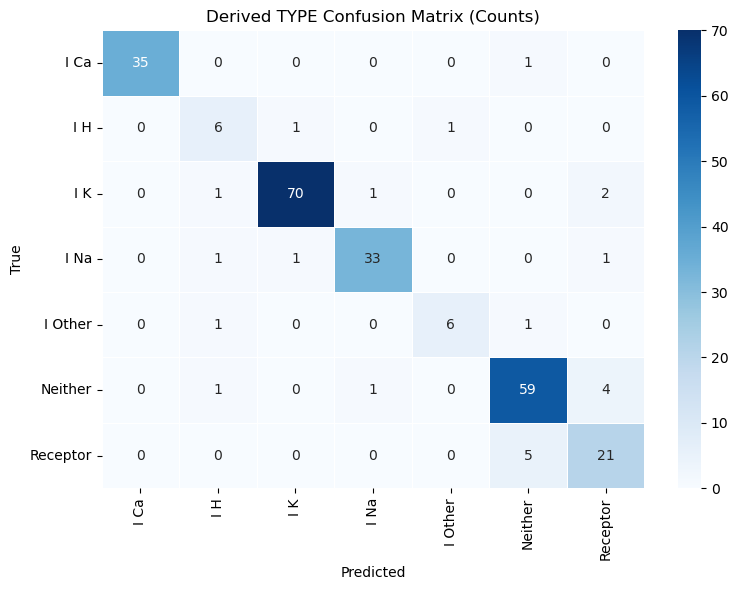

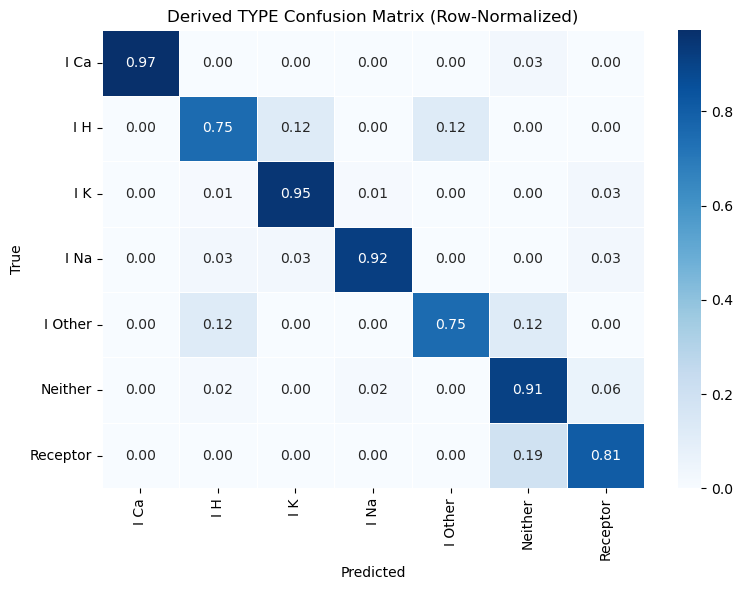

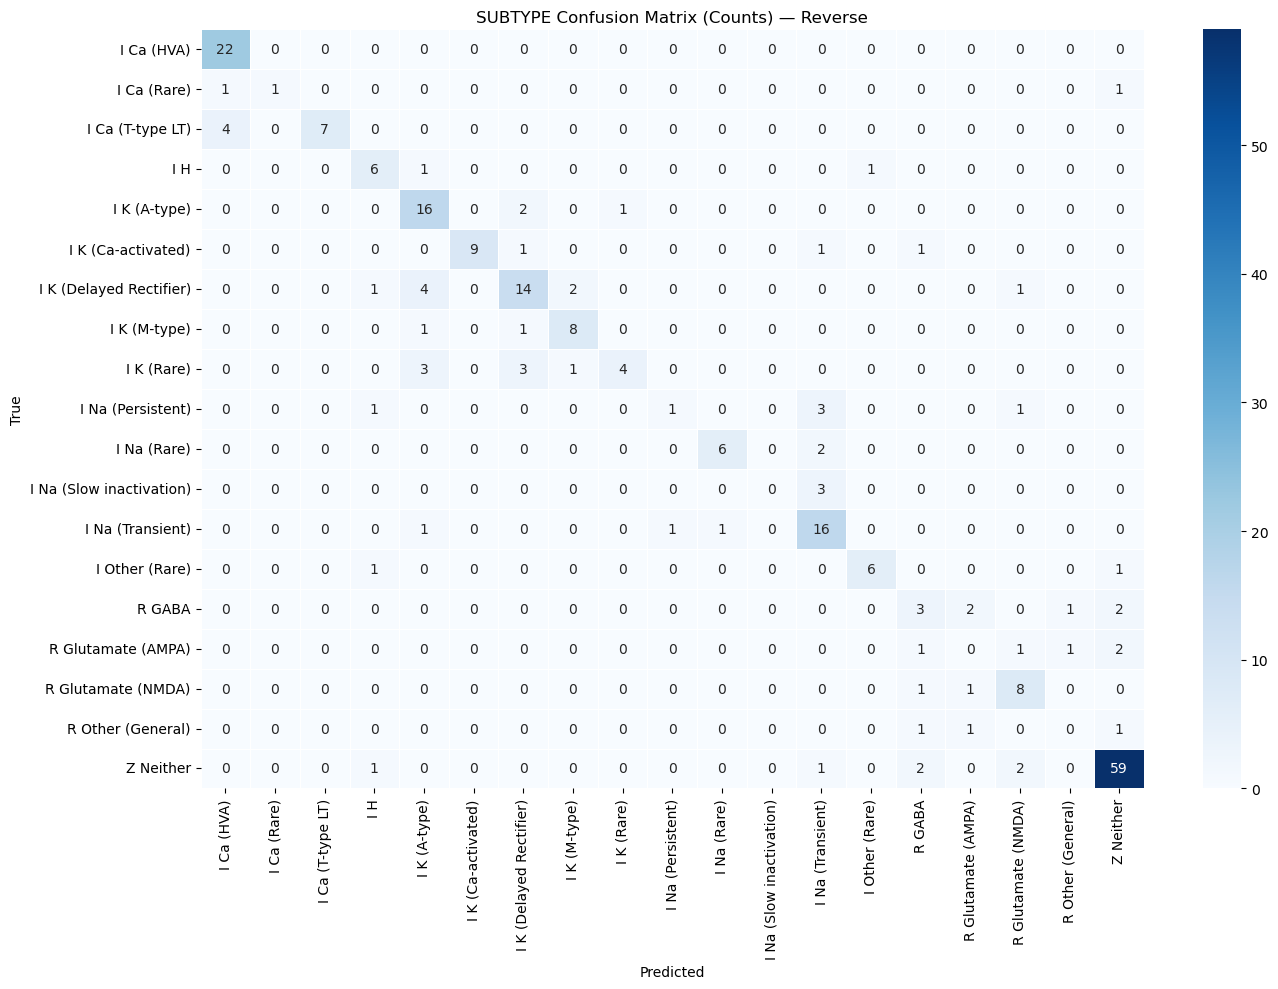

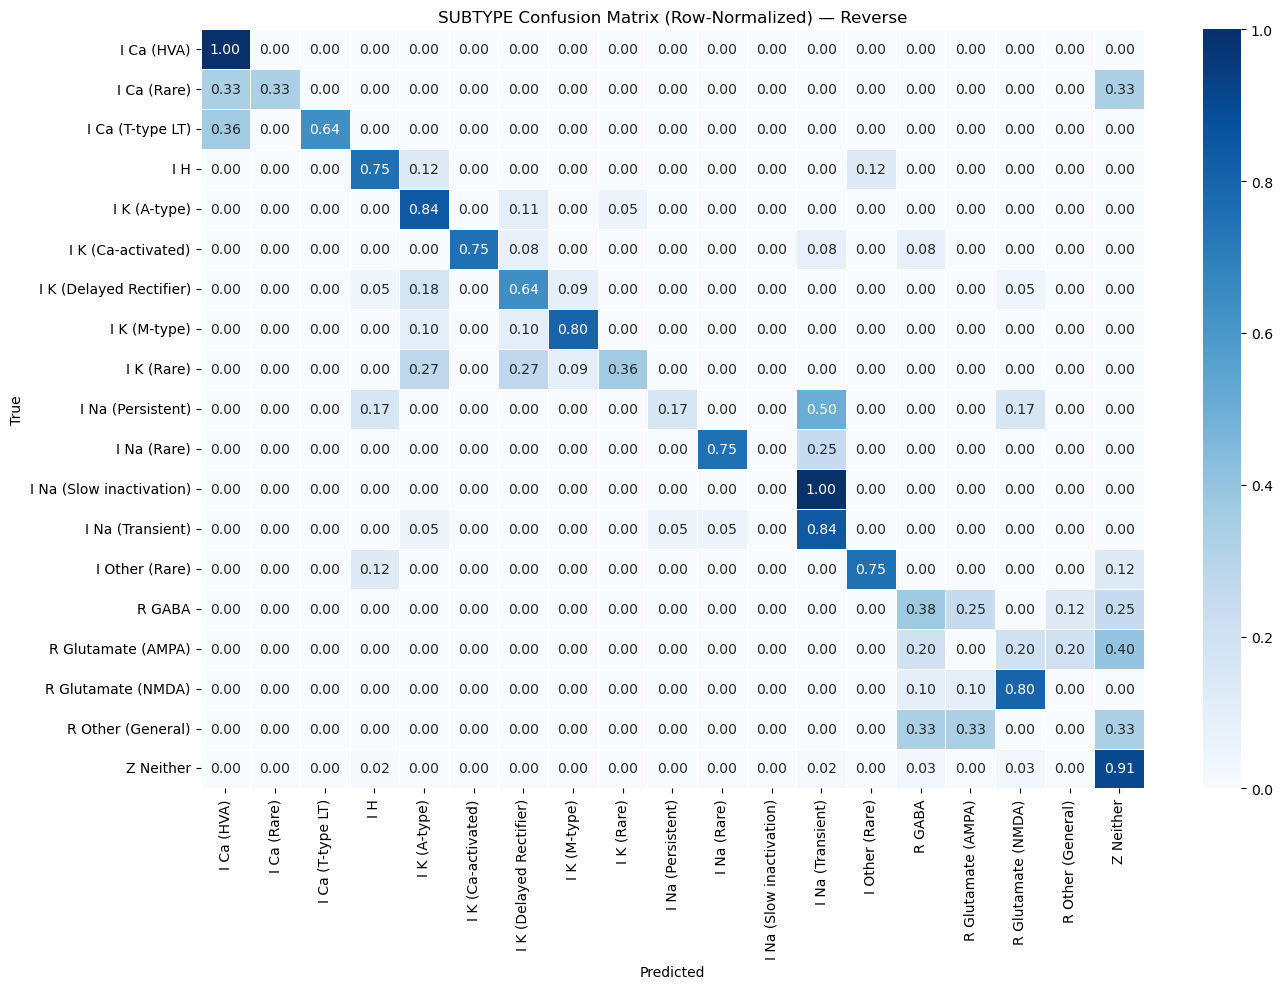

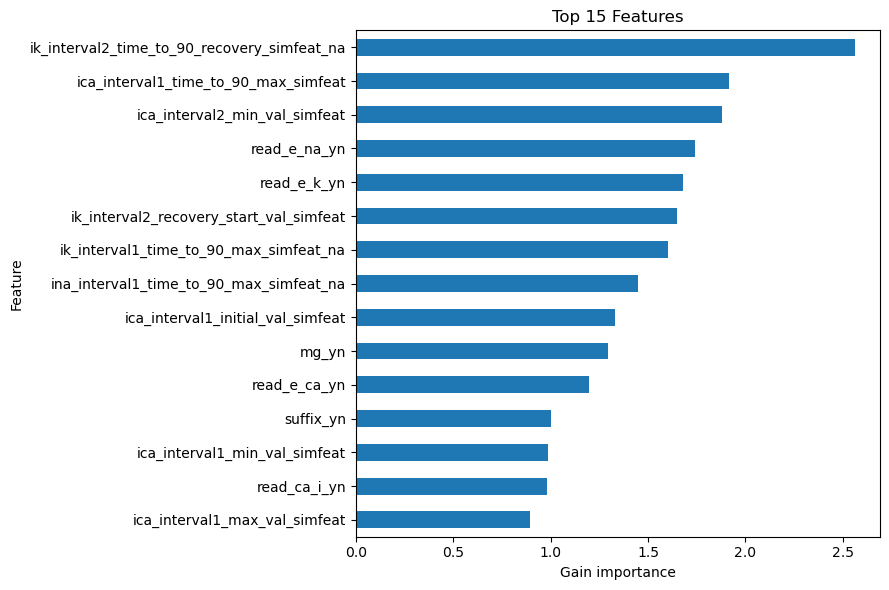

In [77]:
# --- CV splitter (yours) ---
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

# --- Base estimator ---
base_xgb = xgb.XGBClassifier(
objective="multi:softmax",
num_class=len(subtype_encoder.classes_),
eval_metric="mlogloss",
random_state=SEED,
n_jobs=1,
# optional: faster histogram algorithm if available
tree_method="hist"
)

# --- Hyperparameter search space ---
# Keep ranges modest to balance exploration vs. runtime.
param_distributions = {
"max_depth": [4, 6, 8, 10],
"learning_rate": [0.01, 0.03, 0.1, 0.2],
"n_estimators": [200, 400, 800, 1200],
"subsample": [0.6, 0.8, 1.0],
"colsample_bytree": [0.5, 0.8, 1.0],
"min_child_weight": [1, 3, 5],
"gamma": [0, 0.5, 1.0],
"reg_alpha": [0.0, 0.01, 0.1, 1.0],
"reg_lambda": [0.5, 1.0, 2.0],
}

# --- RandomizedSearchCV (uses your cv) ---
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV(
estimator=base_xgb,
param_distributions=param_distributions,
n_iter=40,                 # increase/decrease as needed
scoring="accuracy",
cv=cv,
random_state=SEED,
n_jobs=1,                  # keep 1 if you need strict reproducibility
refit=True,                # refit best params on full training set
verbose=1
)

# --- Run search ---
search.fit(X_train_final, y_subtype_train_enc)
print(f"[Reverse] Best CV accuracy: {search.best_score_:.4f}")
print("[Reverse] Best params:", search.best_params_)

# Best tuned model already refit on full training data
subtype_model = search.best_estimator_

# --- Predict subtype ---
y_subtype_pred_enc_rev = subtype_model.predict(X_test_final)
y_subtype_pred_rev = subtype_encoder.inverse_transform(y_subtype_pred_enc_rev)

# --- Derive TYPE from predicted subtype using lookup ---
# Create a mapping from subtype to type using your ground truth
subtype_to_type_map = ant_df[['label', 'type']].drop_duplicates().set_index('label')['type'].to_dict()

# Map XGB's predicted subtypes to their correct types
y_type_pred_rev = pd.Series(y_subtype_pred_rev).map(subtype_to_type_map)


print("X_test_final:", X_test_final.shape)
print("y_subtype_test:", len(y_subtype_test))
print("y_type_test:", len(y_type_test))
print("y_subtype_pred_rev:", len(y_subtype_pred_rev))



# --- Evaluation ---
print("\n=== Held-Out Evaluation (Reverse: subtype->type) ===")
print("Type Accuracy (derived from subtype):", accuracy_score(y_type_test, y_type_pred_rev))
print("\nSubtype Accuracy (overall):", accuracy_score(y_subtype_test, y_subtype_pred_rev))
print("\nSubtype Classification Report (overall):")
print(classification_report(y_subtype_test, y_subtype_pred_rev))

# --- Confusion matrices ---
type_labels = sorted(pd.Series(y_type_test).unique())
plot_confusion(y_type_test, y_type_pred_rev, labels=type_labels,
title="Derived TYPE Confusion Matrix (Counts)", figsize=(8, 6))
plot_confusion(y_type_test, y_type_pred_rev, labels=type_labels,
title="Derived TYPE Confusion Matrix (Row-Normalized)", normalize="true", figsize=(8, 6))

subtype_labels = sorted(pd.Series(y_subtype_test).unique())
plot_confusion(y_subtype_test, y_subtype_pred_rev, labels=subtype_labels,
title="SUBTYPE Confusion Matrix (Counts) — Reverse", figsize=(14, 10))
plot_confusion(y_subtype_test, y_subtype_pred_rev, labels=subtype_labels,
title="SUBTYPE Confusion Matrix (Row-Normalized) — Reverse", normalize="true", figsize=(14, 10))

# --- Feature importance (reverse) ---
subtype_feat_imp_rev = xgb_gain_importance(subtype_model, X_train_final.columns)
plot_top_features(subtype_feat_imp_rev, "Top 15 Features")

In [78]:
booster = subtype_model.get_booster()

gain  = booster.get_score(importance_type="gain")
cover = booster.get_score(importance_type="cover")
weight = booster.get_score(importance_type="weight")

fi_csv = pd.DataFrame({
    "feature": list(gain.keys()),
    "gain": list(gain.values()),
    "cover": [cover.get(f, 0) for f in gain.keys()],
    "weight": [weight.get(f, 0) for f in gain.keys()]
})

fi_csv.to_csv("../data/pipeline/feature_importance_global.csv", index=False)

In [79]:

# Save model (pickle)
with open("subtype_xgb_model.pkl", "wb") as f:
    pickle.dump(subtype_model, f)

# Save model (json)
subtype_model.save_model("subtype_xgb_model.json")

# Save encoder
with open("subtype_encoder.pkl", "wb") as f:
    pickle.dump(subtype_encoder, f)

# Save mapping
with open("subtype_to_type_map.pkl", "wb") as f:
    pickle.dump(subtype_to_type_map, f)

# Save feature order
with open("feature_order.json", "w") as f:
    json.dump(list(X_train_final.columns), f)


## SHAP Top Features (Overall)

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.


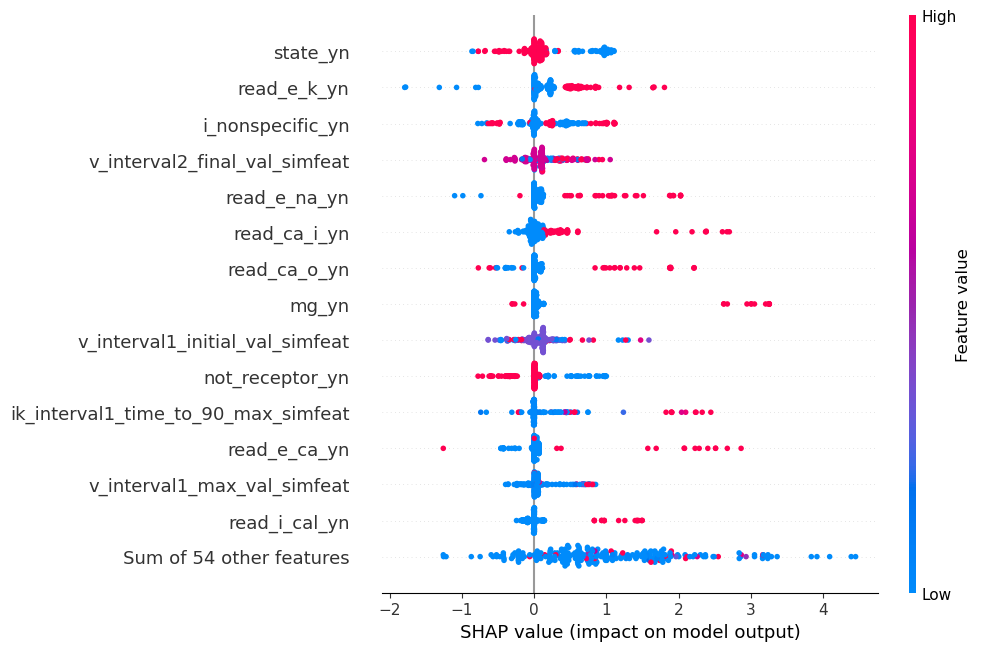

In [80]:
# Build explainer (interventional is usually best for tree models)
explainer = shap.TreeExplainer(subtype_model, feature_perturbation="interventional")

# SHAP values for test set
shap_values = explainer.shap_values(X_test_final)  # list-of-arrays (classic) OR 3D array (newer SHAP)

# Predicted class positions per row (aligns with shap_values class order)
proba = subtype_model.predict_proba(X_test_final)          # shape (n_samples, n_classes)
pred_pos = np.asarray(proba).argmax(axis=1)                # shape (n_samples,)

n_samples, n_features = X_test_final.shape

# Get per-row SHAP for the predicted class, handling both SHAP formats
if isinstance(shap_values, list):
    # shap_values[k] -> (n_samples, n_features) for class k
    shap_pred = np.vstack([shap_values[k][i] for i, k in enumerate(pred_pos)])  # (n_samples, n_features)
else:
    # shap_values -> (n_samples, n_features, n_classes)
    shap_pred = shap_values[np.arange(n_samples), :, pred_pos]                  # (n_samples, n_features)

# Pack into a dataframe
df_shap = pd.DataFrame(shap_pred, columns=X_test_final.columns)
df_shap["file_hash"] = X_test_final.index


# Compute SHAP values for all classes
explainer = shap.TreeExplainer(subtype_model, feature_perturbation="interventional")
shap_values_all = explainer(X_test_final)  # shap.Explanation, shape (n_samples, n_features, n_classes)

# Find predicted class index for each sample
proba = subtype_model.predict_proba(X_test_final)
pred_pos = np.argmax(proba, axis=1)

# Extract SHAP values for the predicted class per row
# (this converts from 3D → 2D)
shap_pred = np.array([shap_values_all.values[i, :, pred_pos[i]] for i in range(len(pred_pos))])

# Create new Explanation object for the selected SHAP values
shap_pred_expl = shap.Explanation(
    values=shap_pred,
    base_values=shap_values_all.base_values.mean(axis=1),  # average base_value across classes
    data=X_test_final,
    feature_names=X_test_final.columns
)

# --- Beeswarm plot ---
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_pred_expl, max_display=15)
plt.show()


# SHAP Top Features (By Class)

In [81]:
subtype_model.classes_


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18])

In [82]:
for i, name in enumerate(subtype_encoder.classes_):
    print(i, name)


0 I Ca (HVA)
1 I Ca (Rare)
2 I Ca (T-type LT)
3 I H
4 I K (A-type)
5 I K (Ca-activated)
6 I K (Delayed Rectifier)
7 I K (M-type)
8 I K (Rare)
9 I Na (Persistent)
10 I Na (Rare)
11 I Na (Slow inactivation)
12 I Na (Transient)
13 I Other (Rare)
14 R GABA
15 R Glutamate (AMPA)
16 R Glutamate (NMDA)
17 R Other (General)
18 Z Neither


SHAP beeswarm — class 0: I Ca (HVA)


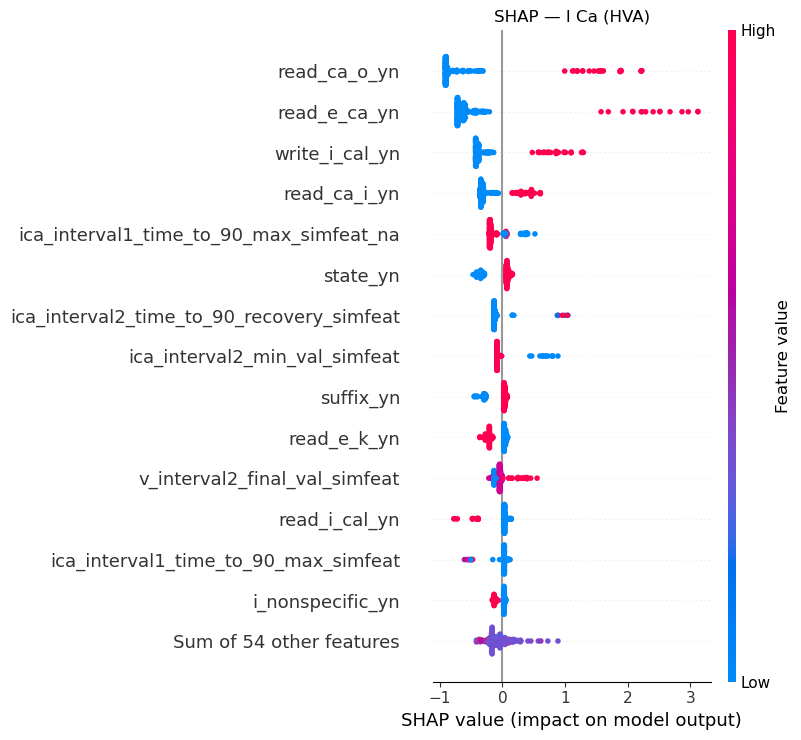

SHAP beeswarm — class 1: I Ca (Rare)


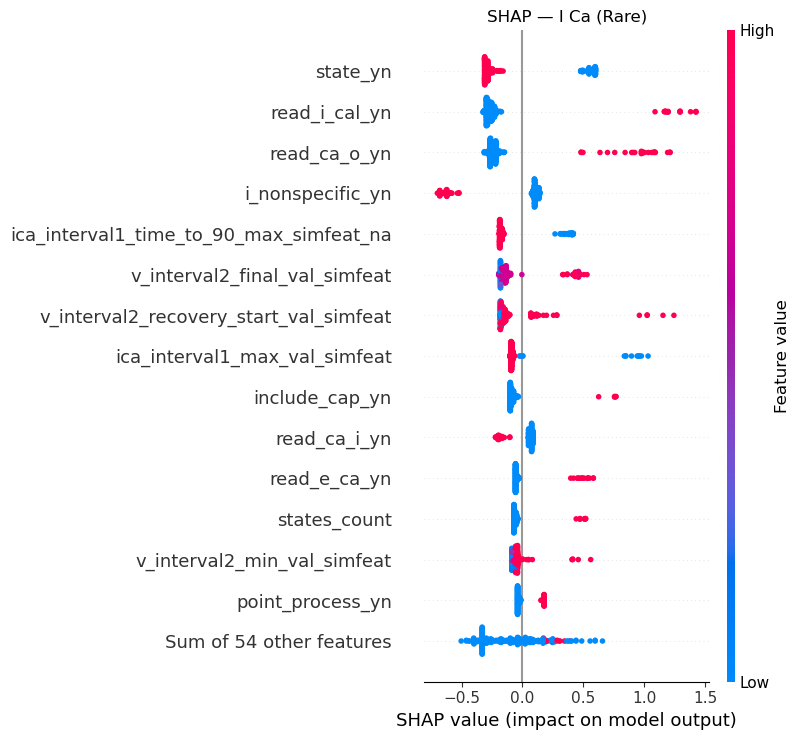

SHAP beeswarm — class 2: I Ca (T-type LT)


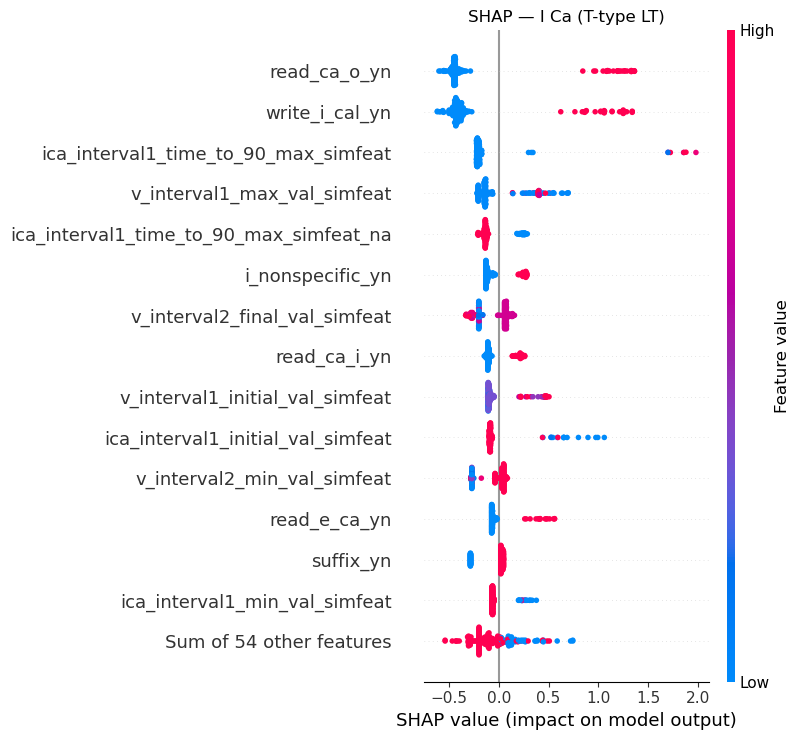

SHAP beeswarm — class 3: I H


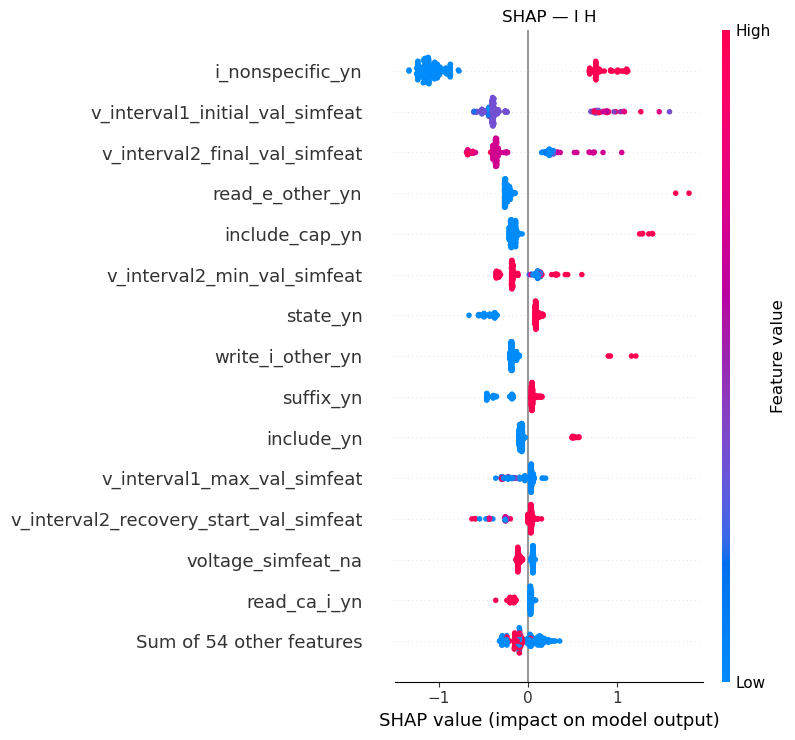

SHAP beeswarm — class 4: I K (A-type)


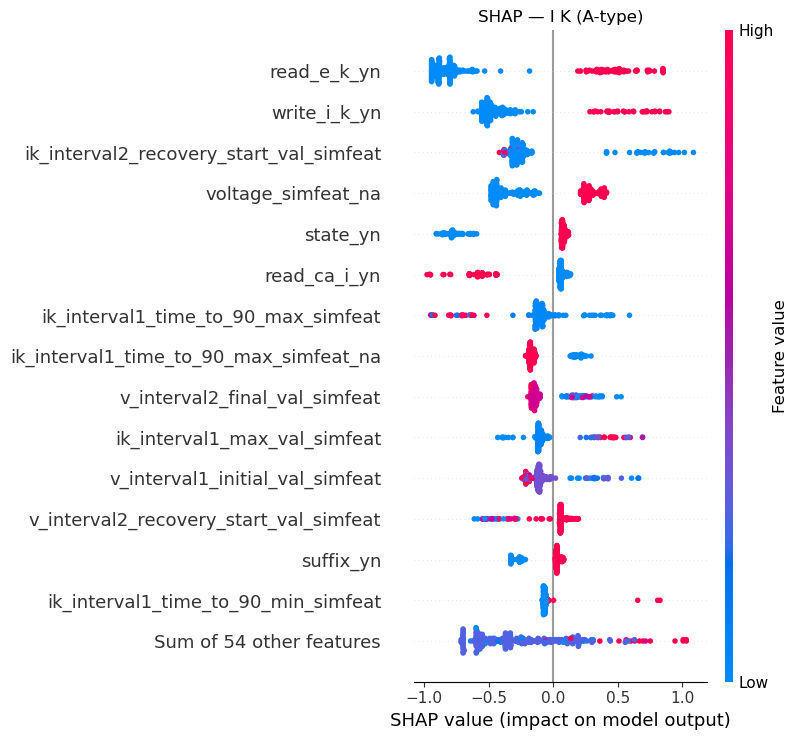

SHAP beeswarm — class 5: I K (Ca-activated)


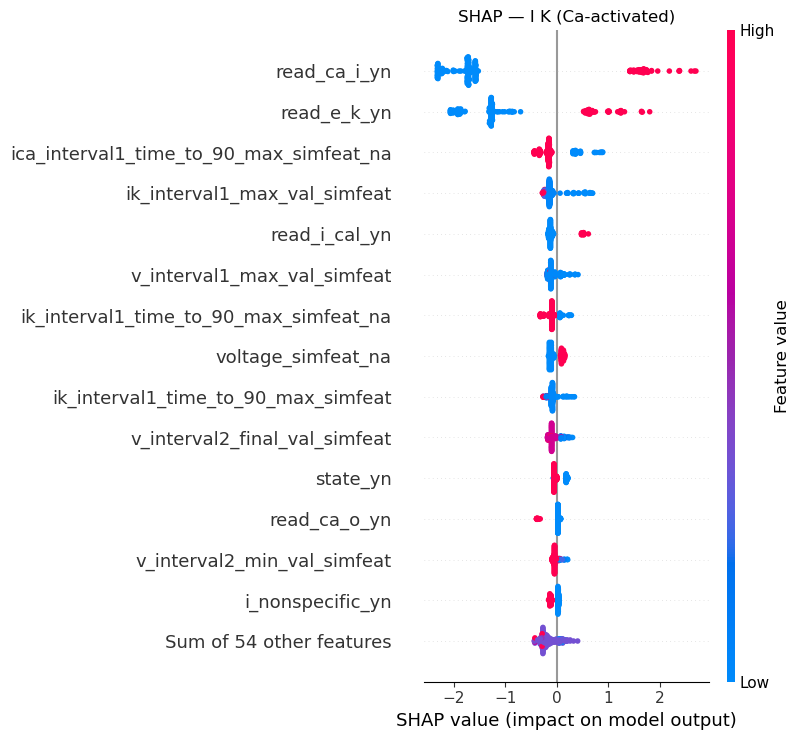

SHAP beeswarm — class 6: I K (Delayed Rectifier)


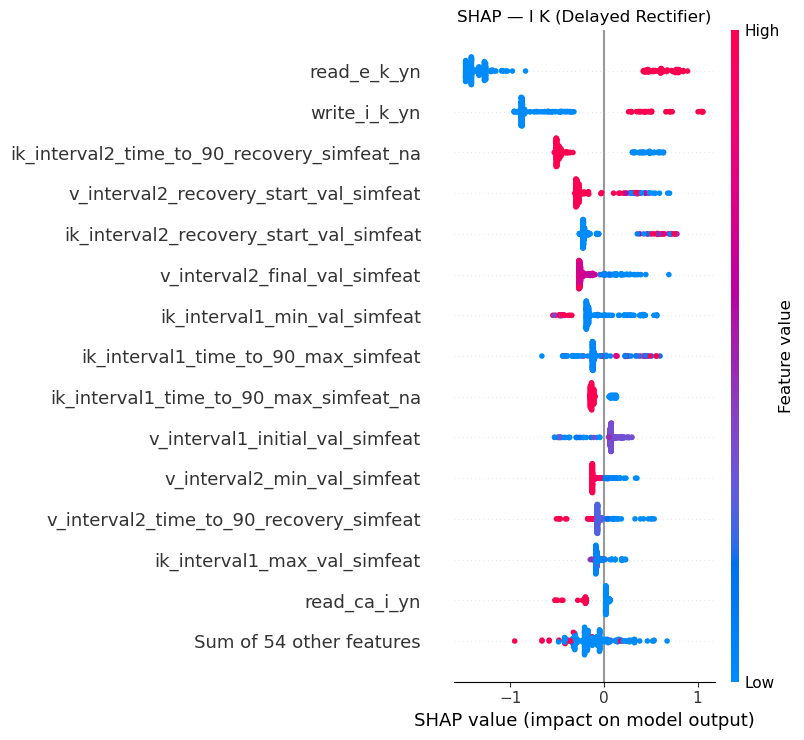

SHAP beeswarm — class 7: I K (M-type)


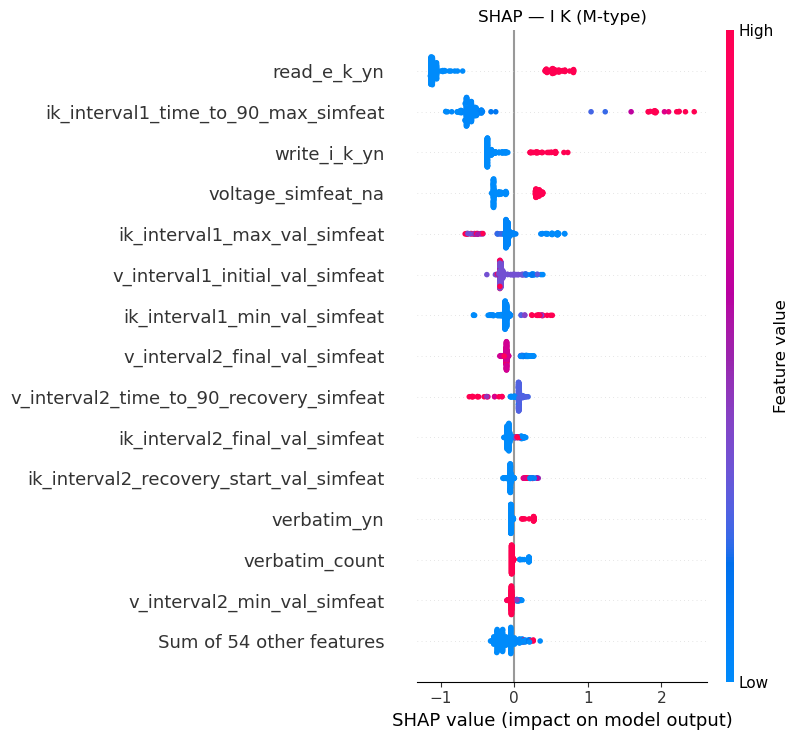

SHAP beeswarm — class 8: I K (Rare)


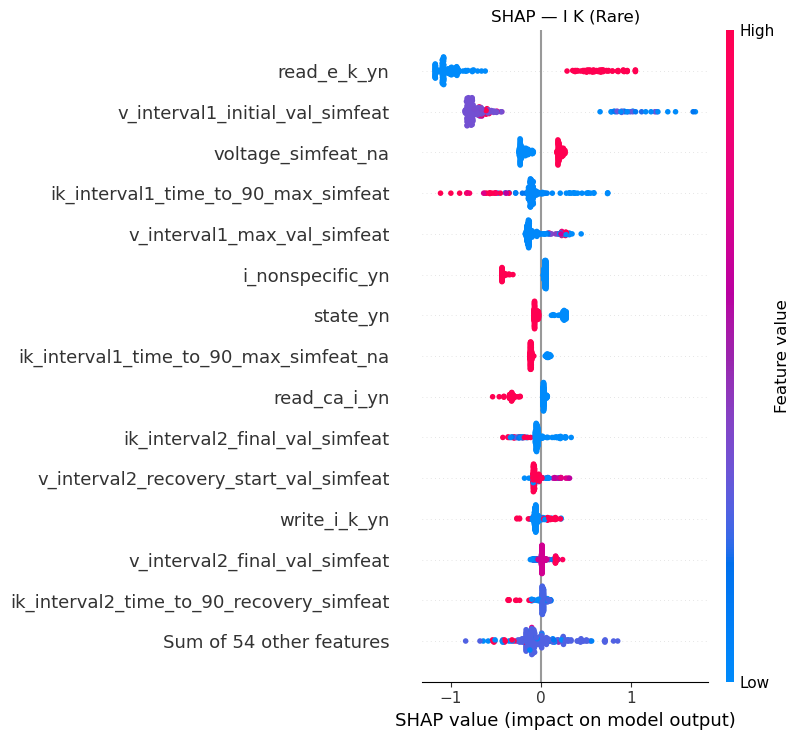

SHAP beeswarm — class 9: I Na (Persistent)


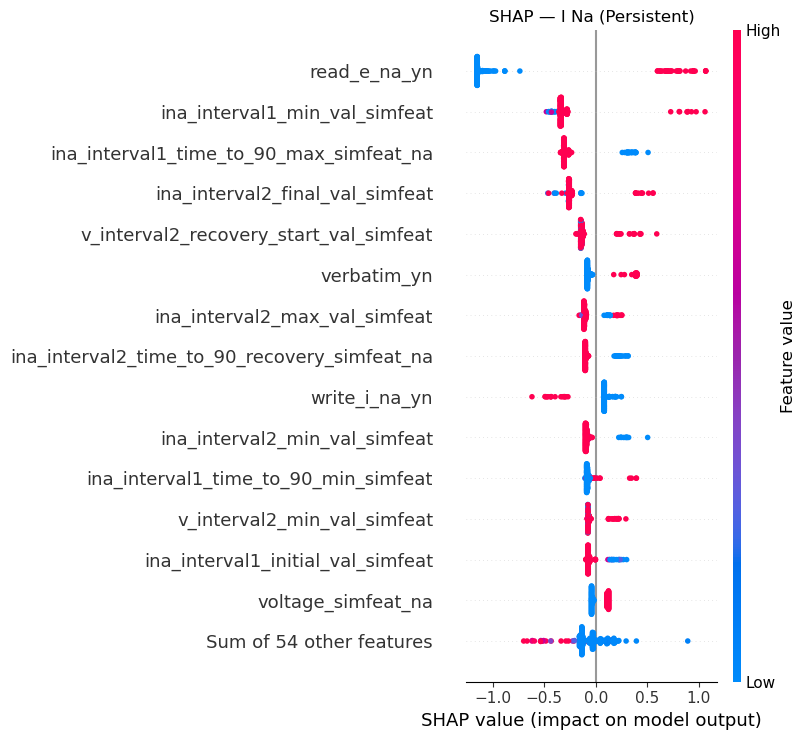

SHAP beeswarm — class 10: I Na (Rare)


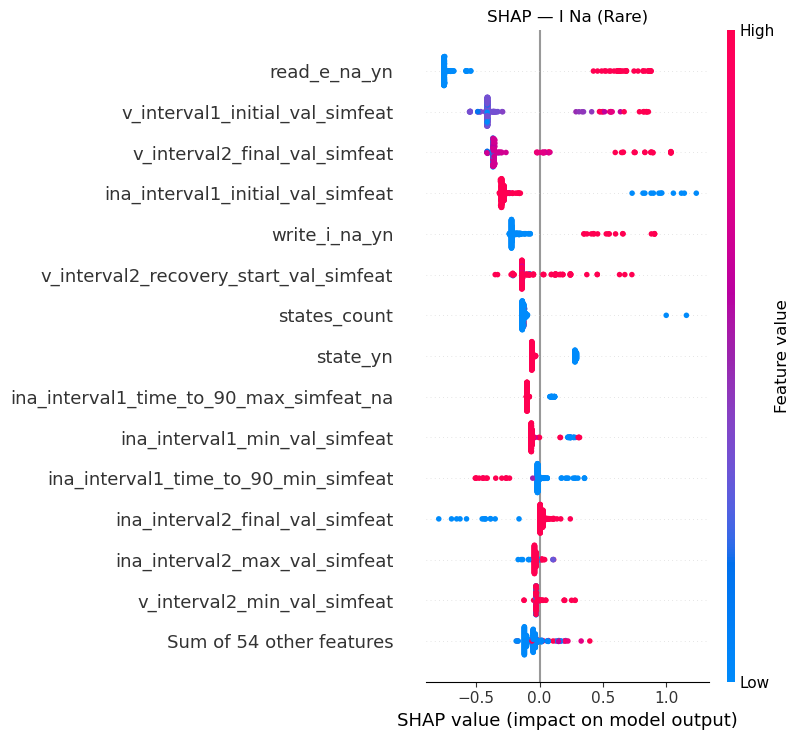

SHAP beeswarm — class 11: I Na (Slow inactivation)


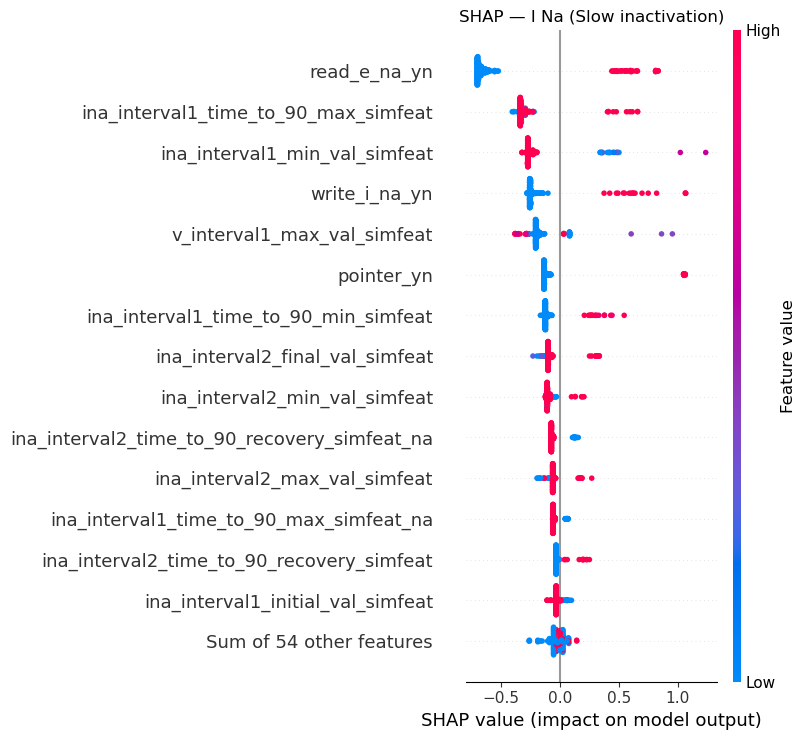

SHAP beeswarm — class 12: I Na (Transient)


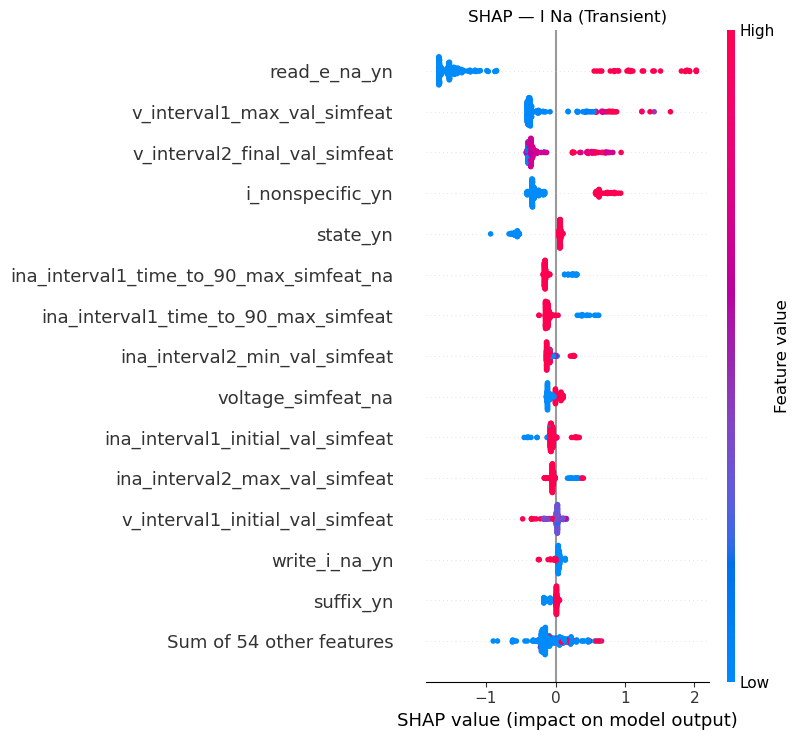

SHAP beeswarm — class 13: I Other (Rare)


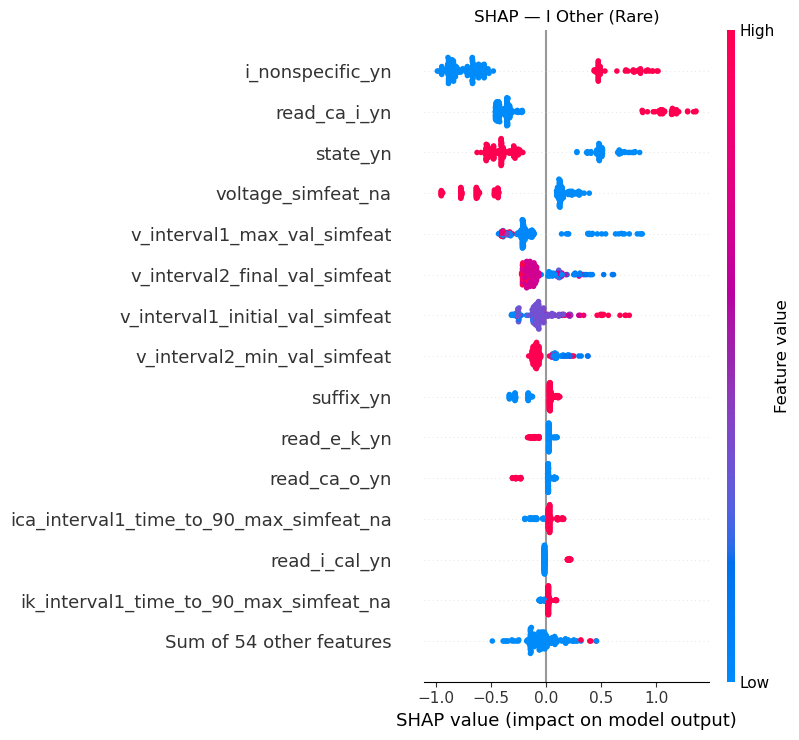

SHAP beeswarm — class 14: R GABA


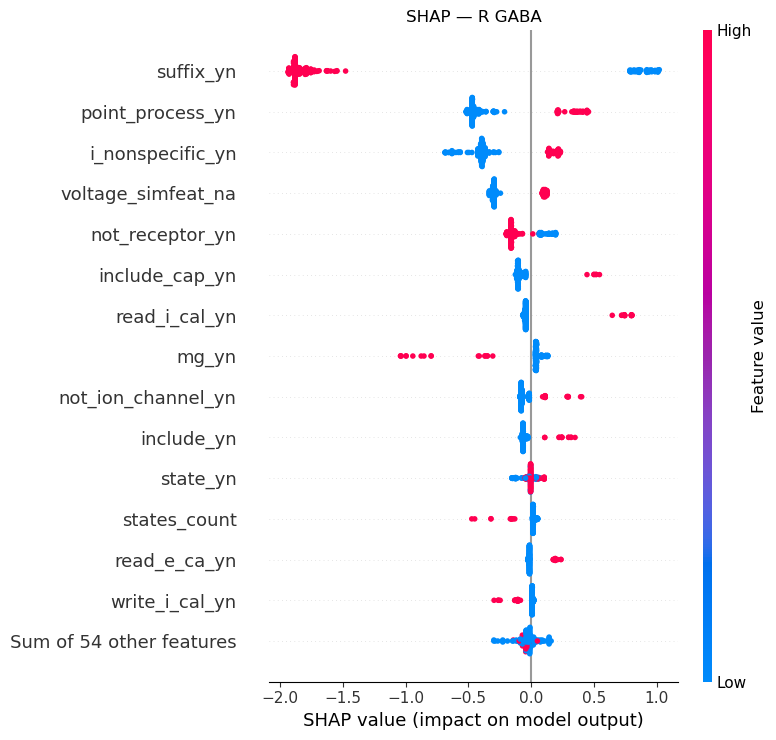

SHAP beeswarm — class 15: R Glutamate (AMPA)


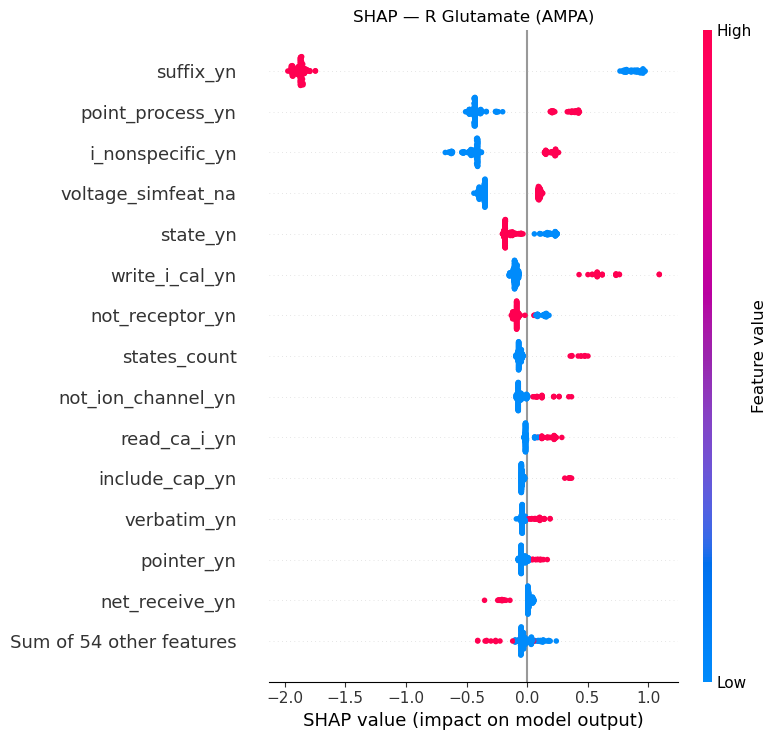

SHAP beeswarm — class 16: R Glutamate (NMDA)


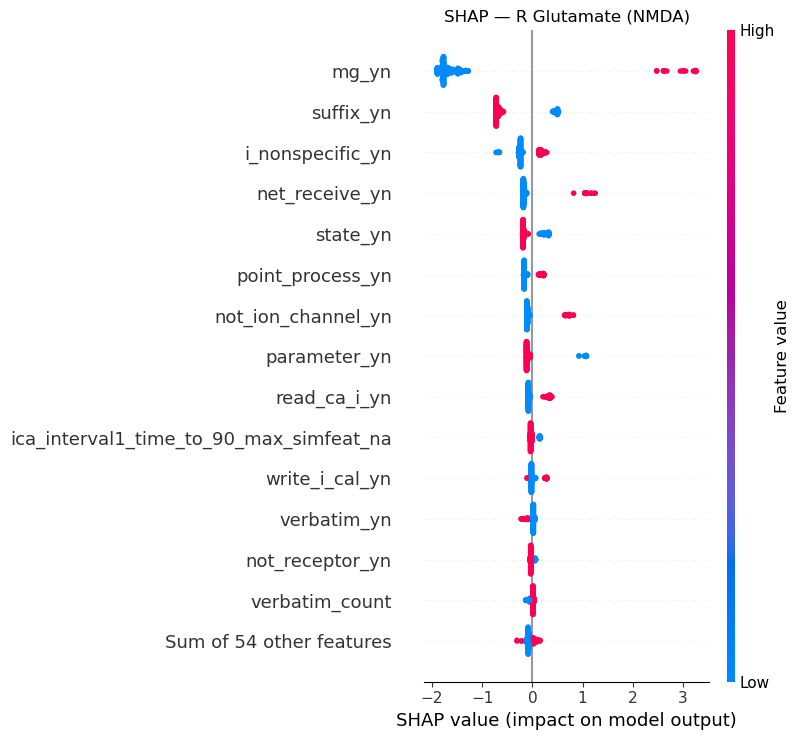

SHAP beeswarm — class 17: R Other (General)


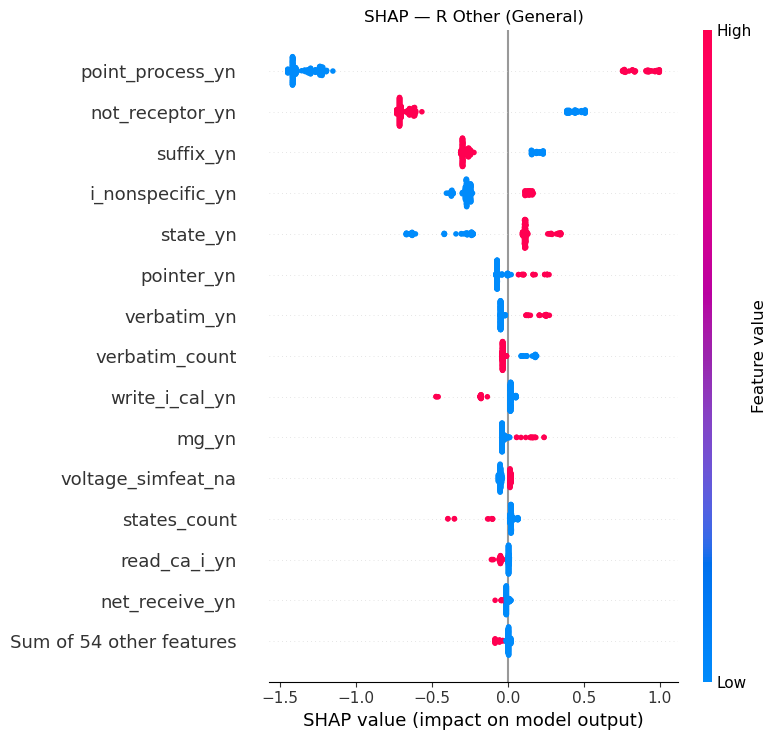

SHAP beeswarm — class 18: Z Neither


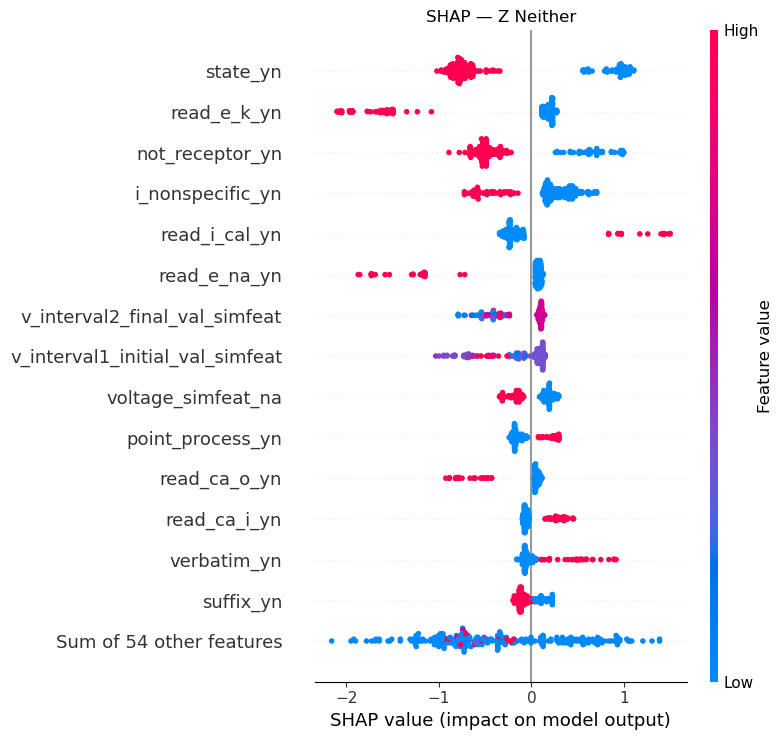

In [83]:
n_classes = shap_values_all.shape[2]
assert n_classes == len(subtype_encoder.classes_)

for class_idx, class_name in enumerate(subtype_encoder.classes_):
    print(f"SHAP beeswarm — class {class_idx}: {class_name}")

    shap.plots.beeswarm(
        shap_values_all[..., class_idx],
        max_display=15,
        show=False
    )

    plt.title(f"SHAP — {class_name}")
    plt.tight_layout()
    plt.show()

## Combining XGB and GPT predictions together

In [84]:
# === Build DataFrame with predictions and truth ===

# True values from test set
true_subtype = y_subtype_test  # string labels
true_type = y_type_test        # string labels

# Build dataframe using reverse model predictions
df_xgb_pred = pd.DataFrame({
    "file_hash": X_test_selected.index,  # or X_test_final.index if X_test_selected isn't defined
    "true_type": true_type.values,
    "true_subtype": true_subtype.values,
    "xgb_pred_type": y_type_pred_rev.values,
    "xgb_pred_subtype": y_subtype_pred_rev
})

df_all = (
    df_xgb_pred
    .merge(
        gpt_both,
        on=["file_hash", "true_type", "true_subtype"],
        how="left"
    )
)



In [85]:

# Optional: add confidence for convenience in R
max_prob = proba.max(axis=1)                       # model confidence of predicted class
df_conf = pd.DataFrame({"file_hash": X_test_final.index, "xgb_pred_prob": max_prob})

# Merge into df_both (which already has truth/preds/match flags)
df_all = df_all.merge(df_shap, on="file_hash", how="left").merge(df_conf, on="file_hash", how="left")

# Export for R
df_all.to_csv("../data/pipeline/predictions_with_shap.csv", index=False)


# GPT Baseline performance

In [86]:


# --- helper: reusable confusion matrix plotter ---
def plot_confusion(y_true, y_pred, title, normalize=None, figsize=(10, 7)):
    # Collect labels present in either true or predicted
    labels = sorted(pd.unique(pd.concat([pd.Series(y_true), pd.Series(y_pred)])))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=figsize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm_df, annot=True, fmt=fmt, cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ====== helpers ======
def _labels_from(*series_list):
    s = pd.concat([pd.Series(s) for s in series_list], ignore_index=True)
    return sorted(s.dropna().unique().tolist())

def plot_cm(ax, y_true, y_pred, labels, title, normalize=None, annot=True):
    if len(y_true) == 0:
        ax.axis('off')
        ax.text(0.5, 0.5, "No samples", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        return
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm, ax=ax, annot=annot, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=90)

In [87]:
#df_both.query("true_type == 'Neither' & xgb_pred_type != 'Neither'")

In [88]:
gpt_bl2

,file_hash,gpt_pred_subtype_og,gpt_pred_type_og,true_type,true_subtype,set,gpt_subtype_set,gpt_type_set,gpt_subtype_set_size,gpt_type_set_size,subtype_correct,type_correct,gpt_bl_pred_subtype,gpt_bl_pred_type
0,007656e71df0c37d29bb65b86cd003a5875216d6c27784...,R Glutamate (NMDA),Receptor,Receptor,R Glutamate (NMDA),test,{R Glutamate (NMDA)},{Receptor},1,1,True,True,R Glutamate (NMDA),Receptor
1,011b7db5371d187d149b406a21bedc61f01fc95dfb1ebd...,R GABA,Receptor,Receptor,R GABA,test,{R GABA},{Receptor},1,1,True,True,R GABA,Receptor
2,0162c32c85a9a1aa57ddf8a38abc8576c32936cc8841f3...,I K (Delayed Rectifier),I K,I K,I K (Delayed Rectifier),test,{I K (Delayed Rectifier)},{I K},1,1,True,True,I K (Delayed Rectifier),I K
3,0231db84198957da3f57500d0b4593734095e8dde485e2...,I K (M-type),I K,I K,I K (M-type),test,{I K (M-type)},{I K},1,1,True,True,I K (M-type),I K
4,0306fd9b4ab1ee084d2f1172d5cf386e43289a15f55718...,I K (A-type),I K,I K,I K (A-type),test,{I K (A-type)},{I K},1,1,True,True,I K (A-type),I K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,fd594a6e6db6942e1cff0c1d9b110853d2855bc7e4a624...,I Other (Rare),I Other,I Other,I Other (Rare),test,{I Other (Rare)},{I Other},1,1,True,True,I Other (Rare),I Other
249,fde6e44e959030d8bf140e74fb170efa57efcbb332bffc...,I Ca (HVA),I Ca,I Ca,I Ca (HVA),test,{I Ca (HVA)},{I Ca},1,1,True,True,I Ca (HVA),I Ca
250,fec43fe8271eeffce50ad177e64f04808d02d42a518a65...,I Ca (HVA),I Ca,I Ca,I Ca (HVA),test,{I Ca (HVA)},{I Ca},1,1,True,True,I Ca (HVA),I Ca
251,ff0ba509ac111f673f0368b413117bf9733cb0189cbb02...,I Ca (Rare),I Ca,I Ca,I Ca (HVA),test,{I Ca (Rare)},{I Ca},1,1,False,True,I Ca (Rare),I Ca


In [89]:
def plot_confusion(y_true, y_pred, title, normalize=None, figsize=(10, 7)):
    # Collect labels present in either true or predicted
    labels = sorted(pd.unique(pd.concat([pd.Series(y_true), pd.Series(y_pred)])))
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=figsize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm_df, annot=True, fmt=fmt, cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


GPT Type Accuracy: 0.9526

GPT Type Classification Report:
              precision    recall  f1-score   support

        I Ca       1.00      0.97      0.99        36
         I H       1.00      0.88      0.93         8
         I K       1.00      1.00      1.00        74
        I Na       1.00      1.00      1.00        36
     I Other       0.64      0.88      0.74         8
     Neither       0.98      0.86      0.92        65
    Receptor       0.79      1.00      0.88        26

    accuracy                           0.95       253
   macro avg       0.92      0.94      0.92       253
weighted avg       0.96      0.95      0.95       253



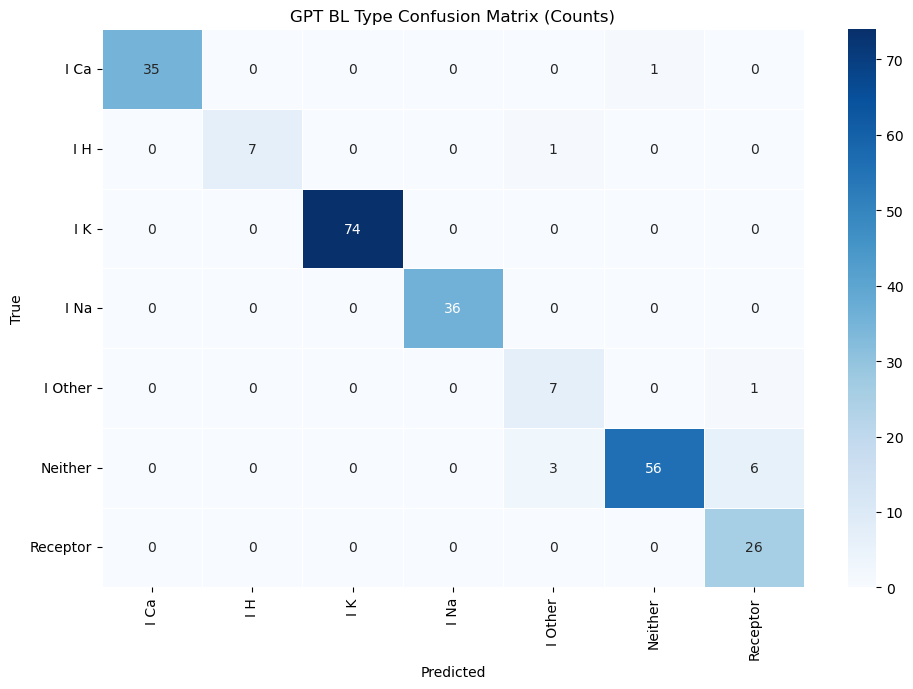

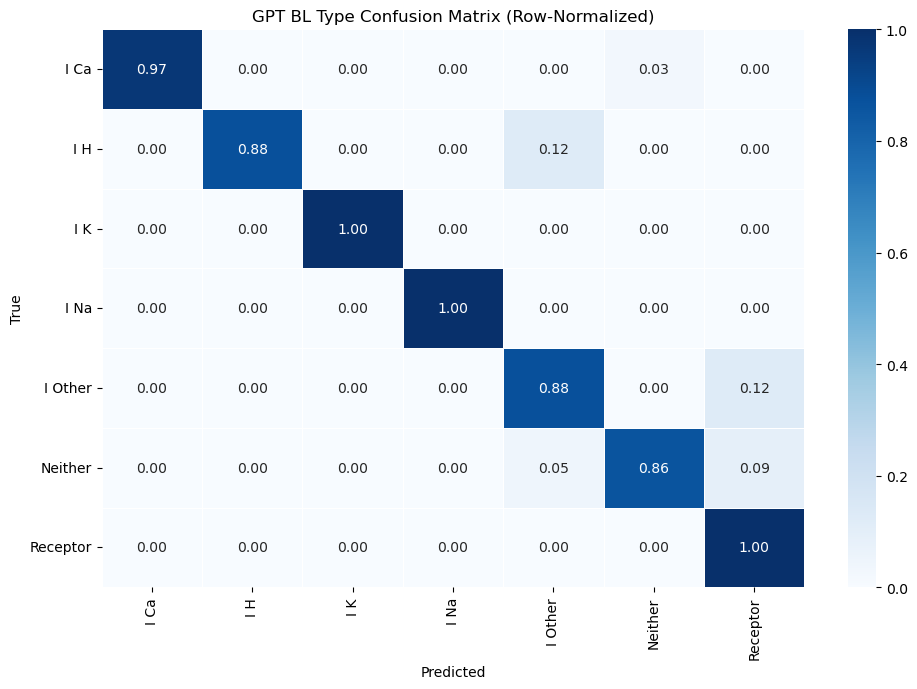


GPT Subtype Accuracy (Overall): 0.8617

GPT Subtype Classification Report (Overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.90      0.86      0.88        22
             I Ca (Rare)       0.00      0.00      0.00         3
        I Ca (T-type LT)       1.00      1.00      1.00        11
                     I H       1.00      0.88      0.93         8
            I K (A-type)       1.00      0.89      0.94        19
      I K (Ca-activated)       1.00      0.83      0.91        12
 I K (Delayed Rectifier)       0.88      1.00      0.94        22
            I K (M-type)       0.91      1.00      0.95        10
              I K (Rare)       0.80      0.73      0.76        11
       I Na (Persistent)       1.00      0.83      0.91         6
             I Na (Rare)       0.50      0.12      0.20         8
I Na (Slow inactivation)       1.00      1.00      1.00         3
        I Na (Transient)       0.73      1.00      0.84

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

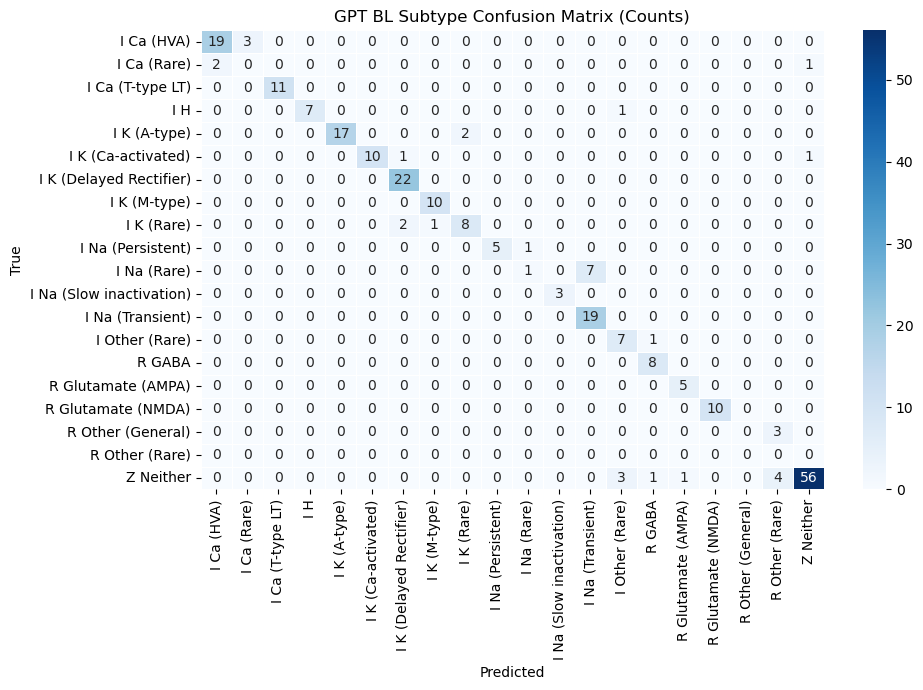

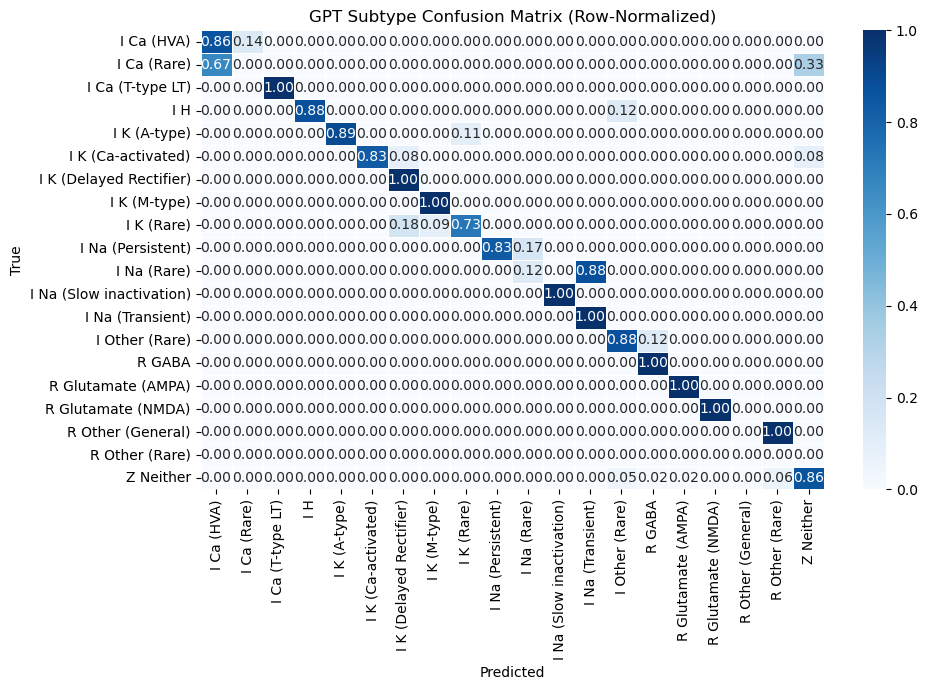

In [90]:


# === Overall GPT Type Accuracy ===
gpt_type_acc = accuracy_score(gpt_bl2["true_type"], gpt_bl2["gpt_bl_pred_type"])
print(f"GPT Type Accuracy: {gpt_type_acc:.4f}")

print("\nGPT Type Classification Report:")
print(classification_report(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_bl_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_bl_pred_type"],
    title="GPT BL Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_bl2["true_type"],
    gpt_bl2["gpt_bl_pred_type"],
    title="GPT BL Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT Subtype Accuracy (no conditioning) ===
gpt_subtype_acc = accuracy_score(
    gpt_bl2["true_subtype"], gpt_bl2["gpt_bl_pred_subtype"]
)
print(f"\nGPT Subtype Accuracy (Overall): {gpt_subtype_acc:.4f}")

print("\nGPT Subtype Classification Report (Overall):")
print(classification_report(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_bl_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_bl_pred_subtype"],
    title="GPT BL Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_bl2["true_subtype"],
    gpt_bl2["gpt_bl_pred_subtype"],
    title="GPT Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)


# GPT Heuristics

GPT AUG Type Accuracy: 0.9526

GPT AUG Type Classification Report:
              precision    recall  f1-score   support

        I Ca       1.00      0.97      0.99        36
         I H       1.00      1.00      1.00         8
         I K       0.99      1.00      0.99        74
        I Na       1.00      1.00      1.00        36
     I Other       0.75      0.75      0.75         8
     Neither       0.98      0.86      0.92        65
    Receptor       0.76      1.00      0.87        26

    accuracy                           0.95       253
   macro avg       0.93      0.94      0.93       253
weighted avg       0.96      0.95      0.95       253



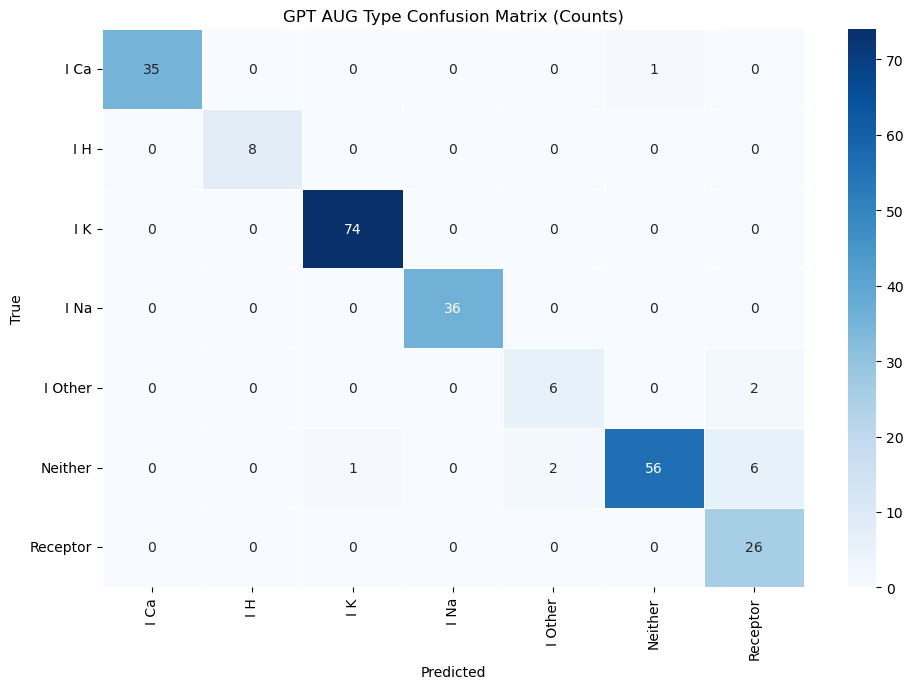

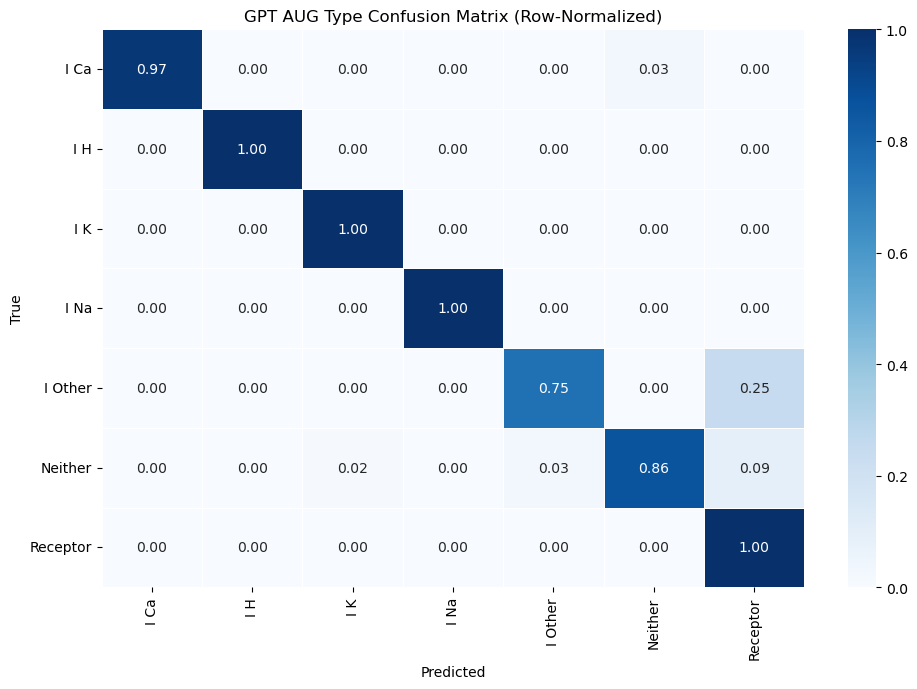


GPT AUG Subtype Accuracy (Overall): 0.8814

GPT AUG Subtype Classification Report (Overall):
                          precision    recall  f1-score   support

              I Ca (HVA)       0.88      1.00      0.94        22
             I Ca (Rare)       0.00      0.00      0.00         3
        I Ca (T-type LT)       1.00      0.91      0.95        11
                     I H       1.00      1.00      1.00         8
            I K (A-type)       1.00      0.95      0.97        19
      I K (Ca-activated)       0.91      0.83      0.87        12
 I K (Delayed Rectifier)       0.85      1.00      0.92        22
            I K (M-type)       1.00      1.00      1.00        10
              I K (Rare)       1.00      0.82      0.90        11
       I Na (Persistent)       1.00      1.00      1.00         6
             I Na (Rare)       1.00      0.12      0.22         8
I Na (Slow inactivation)       1.00      1.00      1.00         3
        I Na (Transient)       0.73      1.00  

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with n

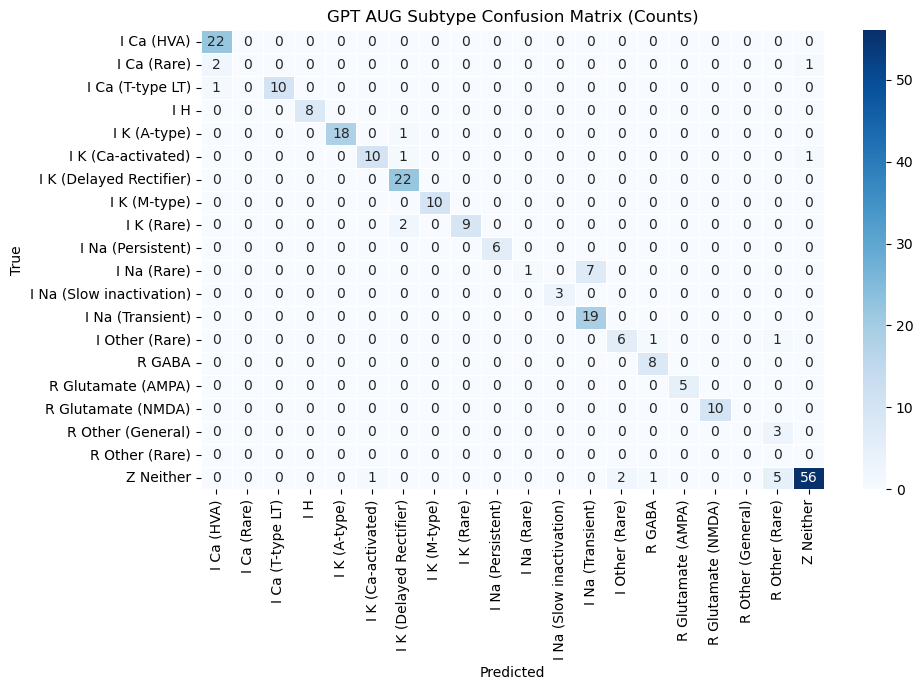

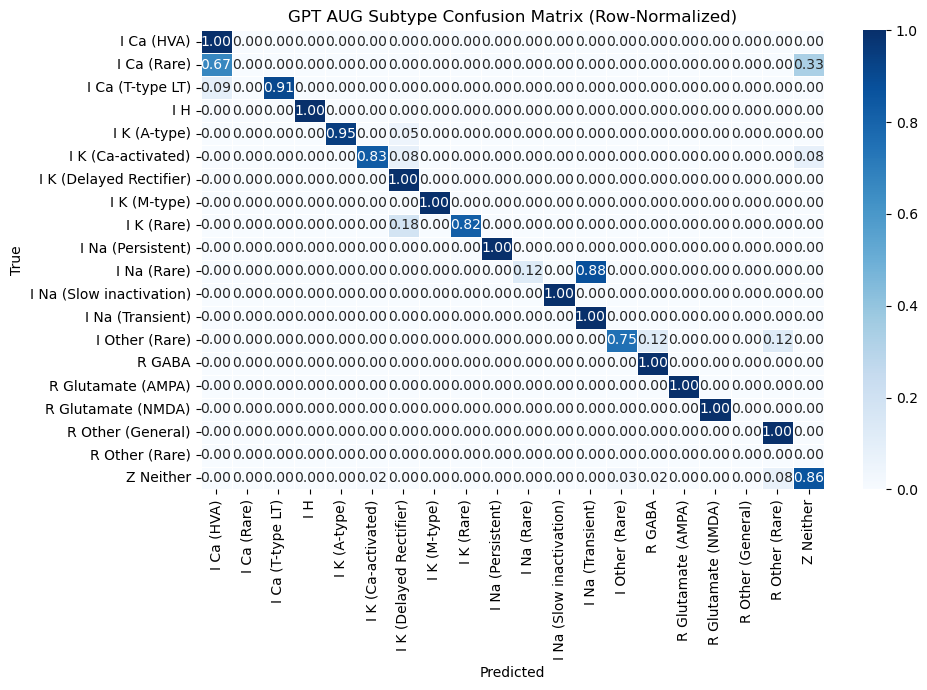

In [91]:
# === Overall GPT AUG Type Accuracy ===
gpt_aug_type_acc = accuracy_score(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_aug_pred_type"]
)
print(f"GPT AUG Type Accuracy: {gpt_aug_type_acc:.4f}")

print("\nGPT AUG Type Classification Report:")
print(classification_report(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_aug_pred_type"]
))

# --- Type confusion matrices (counts + row-normalized) ---
plot_confusion(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_aug_pred_type"],
    title="GPT AUG Type Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_aug2["true_type"],
    gpt_aug2["gpt_aug_pred_type"],
    title="GPT AUG Type Confusion Matrix (Row-Normalized)",
    normalize="true"
)

# === Overall GPT AUG Subtype Accuracy ===
gpt_aug_subtype_acc = accuracy_score(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_aug_pred_subtype"]
)
print(f"\nGPT AUG Subtype Accuracy (Overall): {gpt_aug_subtype_acc:.4f}")

print("\nGPT AUG Subtype Classification Report (Overall):")
print(classification_report(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_aug_pred_subtype"]
))

# --- Subtype confusion matrices (overall) ---
plot_confusion(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_aug_pred_subtype"],
    title="GPT AUG Subtype Confusion Matrix (Counts)",
    normalize=None
)

plot_confusion(
    gpt_aug2["true_subtype"],
    gpt_aug2["gpt_aug_pred_subtype"],
    title="GPT AUG Subtype Confusion Matrix (Row-Normalized)",
    normalize="true"
)


# Merging them

=== Accuracy Summary ===
XGB: Type=0.909, Subtype=0.735
GPT-BL: Type=0.953, Subtype=0.862
GPT-AUG: Type=0.953, Subtype=0.881


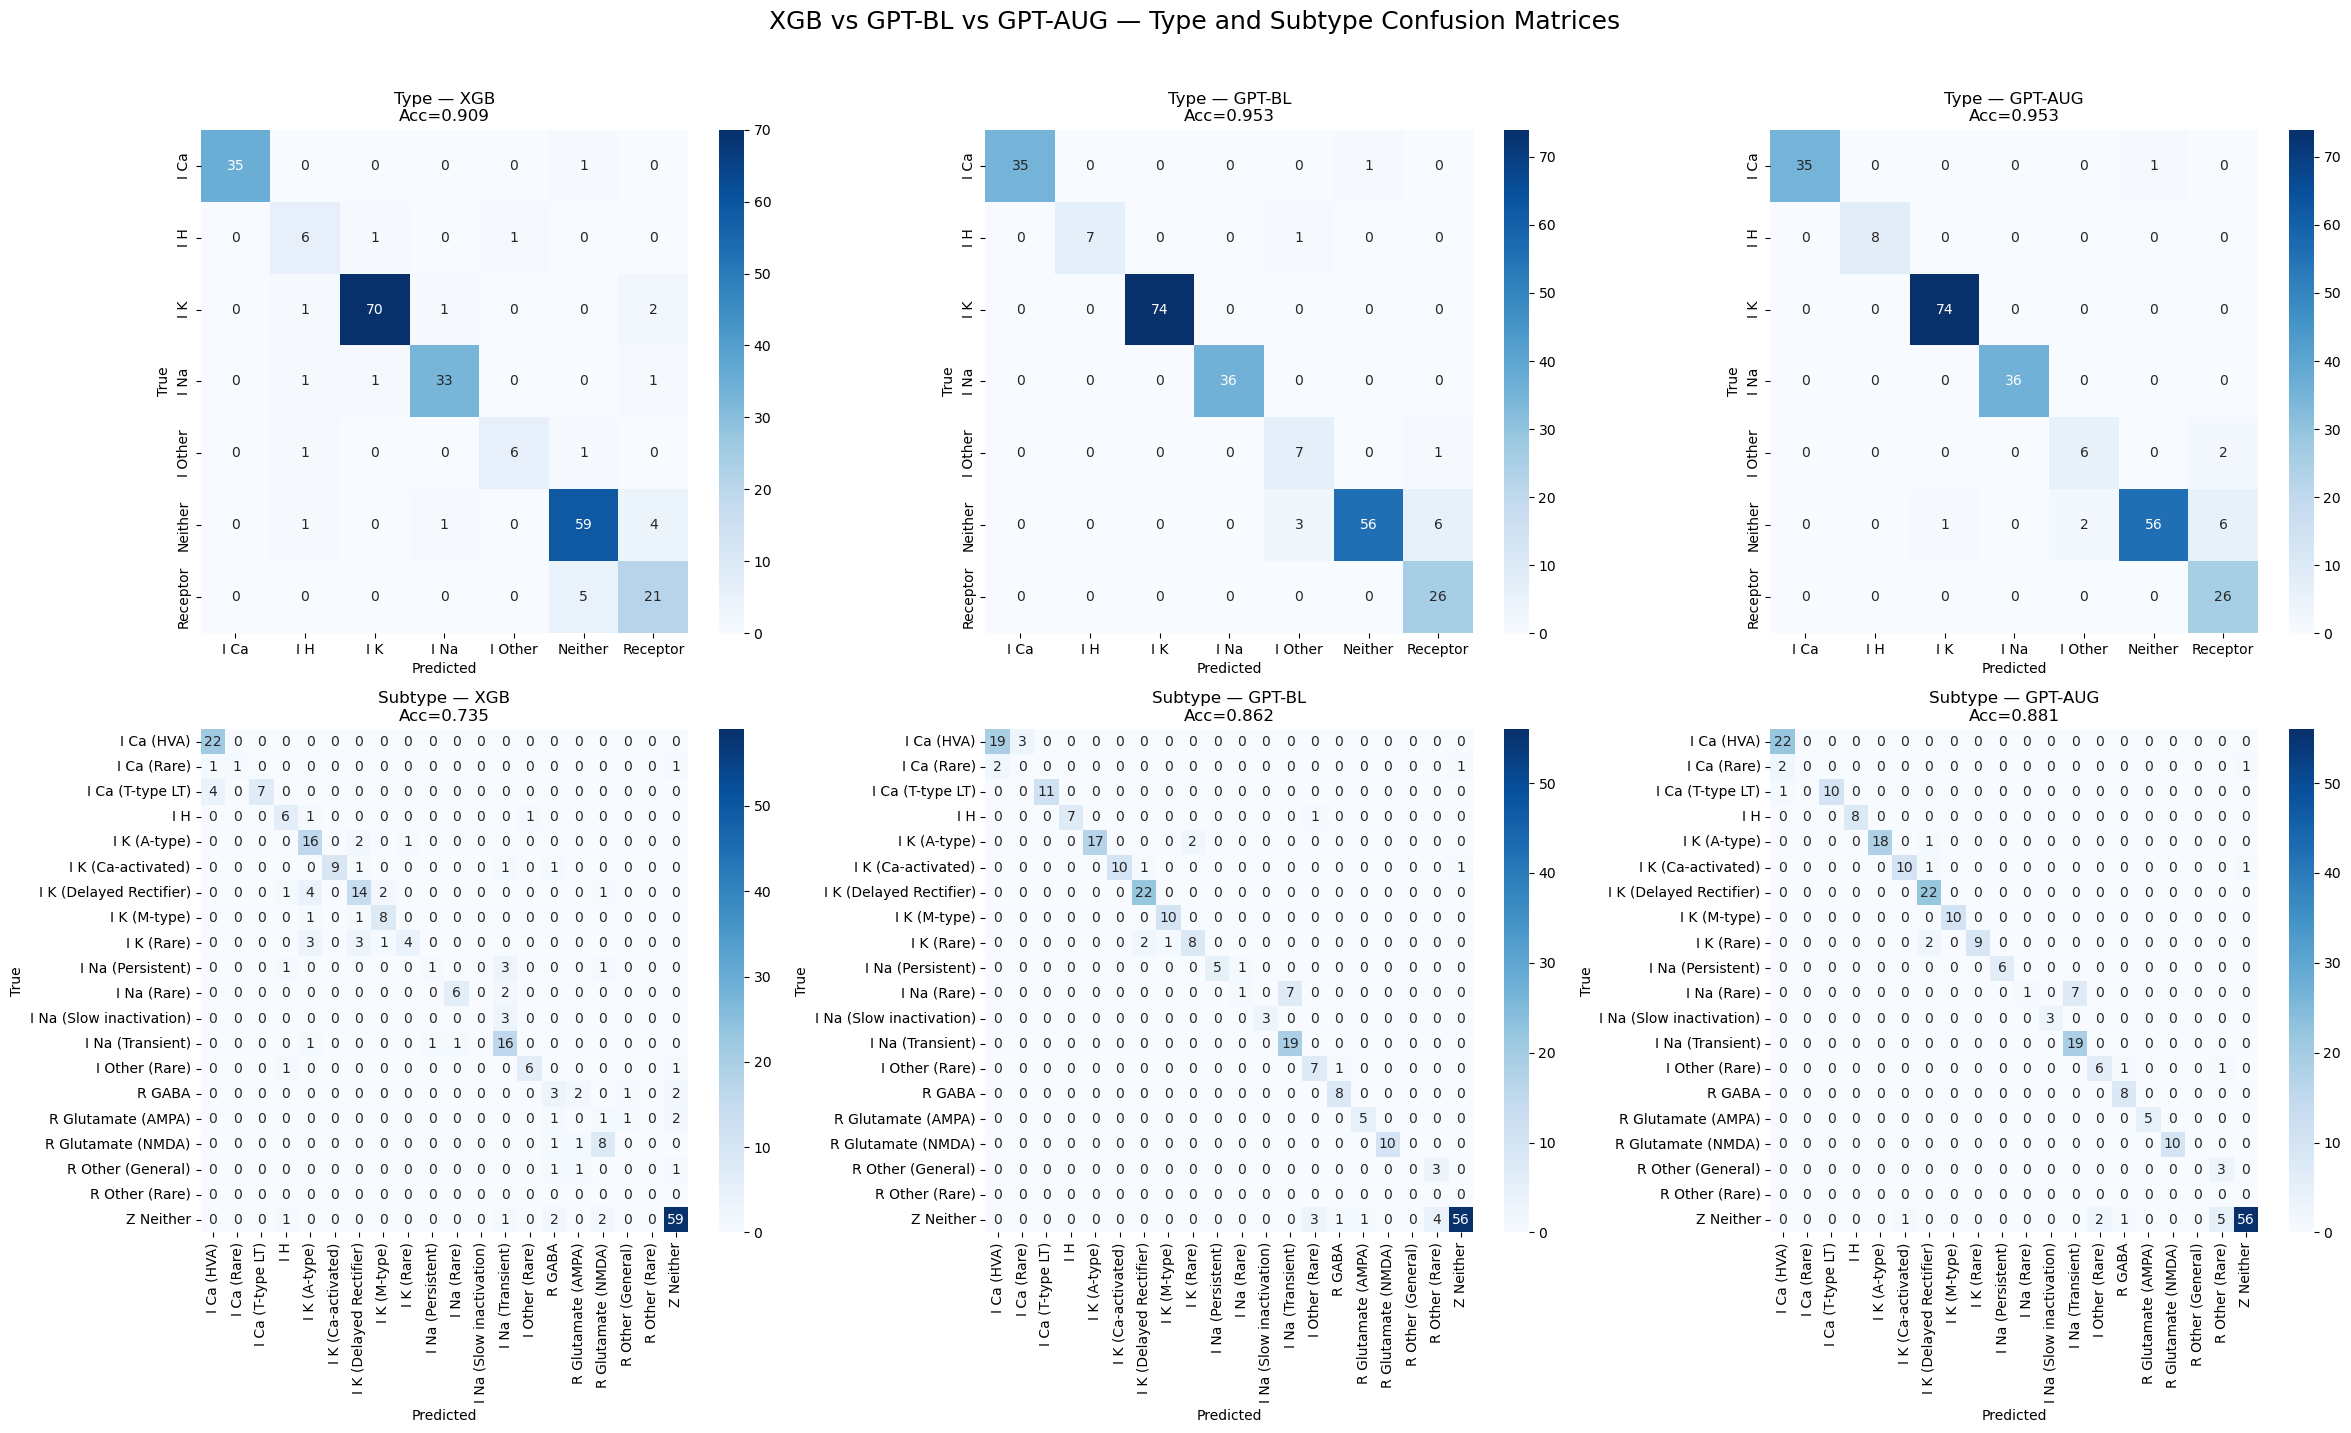

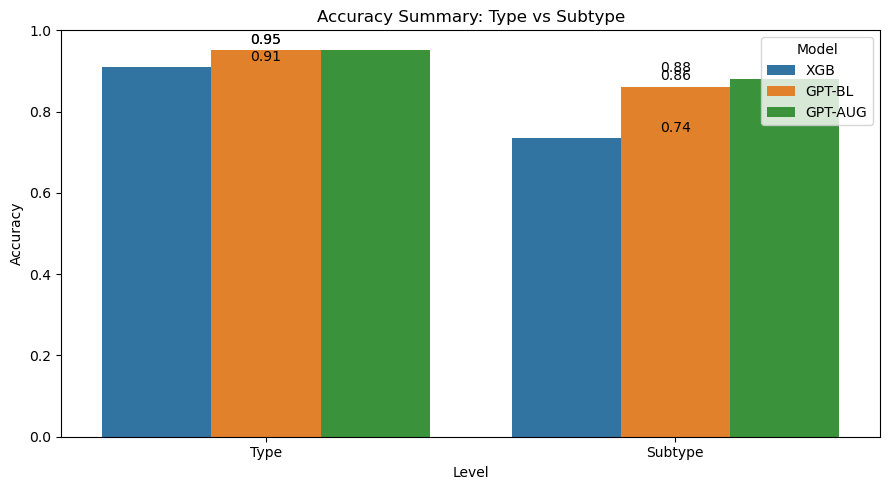


=== Classification Reports ===

--- XGB (Subtype) ---
                          precision    recall  f1-score   support

              I Ca (HVA)       0.81      1.00      0.90        22
             I Ca (Rare)       1.00      0.33      0.50         3
        I Ca (T-type LT)       1.00      0.64      0.78        11
                     I H       0.60      0.75      0.67         8
            I K (A-type)       0.62      0.84      0.71        19
      I K (Ca-activated)       1.00      0.75      0.86        12
 I K (Delayed Rectifier)       0.67      0.64      0.65        22
            I K (M-type)       0.73      0.80      0.76        10
              I K (Rare)       0.80      0.36      0.50        11
       I Na (Persistent)       0.50      0.17      0.25         6
             I Na (Rare)       0.86      0.75      0.80         8
I Na (Slow inactivation)       0.00      0.00      0.00         3
        I Na (Transient)       0.62      0.84      0.71        19
          I Other (R

/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/home/imc33/.conda/envs/mod-annotation/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in la

In [92]:
# ---------- helpers ----------
def _labels_from(*series):
    """Collect sorted unique labels across multiple series."""
    labels = set()
    for s in series:
        labels |= set(pd.Series(s).dropna().unique())
    return sorted(labels)


def plot_cm(ax, y_true, y_pred, labels, title, normalize=None):
    """Plot confusion matrix on a given axis."""
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(
        y_true, y_pred, labels=labels, normalize=normalize
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)


# ============================================================
# 1) Assemble labels across ALL models
# ============================================================

type_labels = _labels_from(
    df_all["true_type"],
    df_all["xgb_pred_type"],
    df_all["gpt_bl_pred_type"],
    df_all["gpt_aug_pred_type"],
)

subtype_labels = _labels_from(
    df_all["true_subtype"],
    df_all["xgb_pred_subtype"],
    df_all["gpt_bl_pred_subtype"],
    df_all["gpt_aug_pred_subtype"],
)


# ============================================================
# 2) Accuracies
# ============================================================

acc = {
    "XGB": {
        "Type": accuracy_score(df_all["true_type"], df_all["xgb_pred_type"]),
        "Subtype": accuracy_score(df_all["true_subtype"], df_all["xgb_pred_subtype"]),
    },
    "GPT-BL": {
        "Type": accuracy_score(df_all["true_type"], df_all["gpt_bl_pred_type"]),
        "Subtype": accuracy_score(df_all["true_subtype"], df_all["gpt_bl_pred_subtype"]),
    },
    "GPT-AUG": {
        "Type": accuracy_score(df_all["true_type"], df_all["gpt_aug_pred_type"]),
        "Subtype": accuracy_score(df_all["true_subtype"], df_all["gpt_aug_pred_subtype"]),
    },
}

print("=== Accuracy Summary ===")
for model in acc:
    print(
        f"{model}: "
        f"Type={acc[model]['Type']:.3f}, "
        f"Subtype={acc[model]['Subtype']:.3f}"
    )


# ============================================================
# 3) Confusion matrices — 2 rows × 3 columns
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(24, 14))

models = [
    ("XGB", "xgb_pred_type", "xgb_pred_subtype"),
    ("GPT-BL", "gpt_bl_pred_type", "gpt_bl_pred_subtype"),
    ("GPT-AUG", "gpt_aug_pred_type", "gpt_aug_pred_subtype"),
]

# ---- Type row ----
for j, (name, type_col, _) in enumerate(models):
    plot_cm(
        axes[0, j],
        df_all["true_type"],
        df_all[type_col],
        type_labels,
        title=f"Type — {name}\nAcc={acc[name]['Type']:.3f}",
        normalize=None
    )

# ---- Subtype row ----
for j, (name, _, subtype_col) in enumerate(models):
    plot_cm(
        axes[1, j],
        df_all["true_subtype"],
        df_all[subtype_col],
        subtype_labels,
        title=f"Subtype — {name}\nAcc={acc[name]['Subtype']:.3f}",
        normalize=None
    )

fig.suptitle(
    "XGB vs GPT-BL vs GPT-AUG — Type and Subtype Confusion Matrices",
    fontsize=18,
    y=1.02
)
plt.tight_layout()
plt.show()


# ============================================================
# 4) Accuracy bar chart
# ============================================================

acc_df = pd.DataFrame([
    {"Model": model, "Level": level, "Accuracy": acc[model][level]}
    for model in acc
    for level in ["Type", "Subtype"]
])

plt.figure(figsize=(9, 5))
sns.barplot(
    data=acc_df,
    x="Level",
    y="Accuracy",
    hue="Model",
    hue_order=["XGB", "GPT-BL", "GPT-AUG"]
)
plt.ylim(0, 1)
plt.title("Accuracy Summary: Type vs Subtype")

for i, row in acc_df.iterrows():
    plt.text(
        x=0 if row["Level"] == "Type" else 1,
        y=row["Accuracy"] + 0.015,
        s=f"{row['Accuracy']:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ============================================================
# (Optional) Classification reports
# ============================================================

print("\n=== Classification Reports ===")

print("\n--- XGB (Subtype) ---")
print(classification_report(
    df_all["true_subtype"], df_all["xgb_pred_subtype"]
))

print("\n--- GPT-BL (Subtype) ---")
print(classification_report(
    df_all["true_subtype"], df_all["gpt_bl_pred_subtype"]
))

print("\n--- GPT-AUG (Subtype) ---")
print(classification_report(
    df_all["true_subtype"], df_all["gpt_aug_pred_subtype"]
))
